In [21]:
import importlib

import pedestrian
import ModificationFactors

importlib.reload(pedestrian)
importlib.reload(ModificationFactors)

from ModificationFactors import run_simulation

In [11]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import torch
torch.set_num_threads(1)

import multiprocessing as mp
import numpy as np
import matplotlib.pyplot as plt
from ModificationFactors import run_simulation

# -----------------------------
# SETTINGS
# -----------------------------
NUM_SIMULATIONS = 1
NUM_PROCESSES = 10

densities = [0.0333, 0.1667, 0.3333, 0.5000, 0.6667, 0.8333, 1.0]
#bridge_frequencies = [ 0.31, 0.45, 0.5, 0.55, 0.6, 0.65, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0, 2.25, 2.5, 2.75, 3.0, 3.25, 3.5, 3.75, 4.0, 4.25, 4.5, 4.75, 5.0, 5.2, 5.25, 5.5, 5.6, 5.75, 5.8, 5.9, 6.0, 6.15, 6.2, 6.25, 6.3,6.4, 6.5,6.6, 6.75, 7.0, 7.25, 7.5, 8.0, 8.5, 9.0, 9.5, 10.0, 15.0, 20.0, 30.0]
damping_values = [0.005, 0.01, 0.015, 0.02, 0.025, 0.03]

frequency_bands = {
    "1.25_to_2.50": np.round(np.arange(1.25, 2.50 + 0.001, 0.01), 3),
    "2.50_to_4.60": np.round(np.arange(2.50, 4.60 + 0.001, 0.01), 3),
}


length = 50.0
width = 2.0
peddamp = 0.25
pedBodyF = 3.10
Linearmass = 500.0

if __name__ == "__main__":

    try:
        mp.set_start_method("spawn")
    except RuntimeError:
        pass

    rng = np.random.default_rng(12345)

    # results_all[band_name][beamdamp][bf][density] = {...}
    results_all = {}

    ctx = mp.get_context("spawn")

    with ctx.Pool(processes=NUM_PROCESSES) as pool:

        for band_name, bridge_frequencies in frequency_bands.items():

            print(f"\n==============================")
            print(f"Running frequency band: {band_name}")
            print(f"==============================")

            results_all[band_name] = {}

            for beamdamp in damping_values:

                print(f"\nRunning structural damping = {beamdamp}")
                results_all[band_name][beamdamp] = {}

                for bf in bridge_frequencies:

                    print(f"   Running bridge frequency = {bf} Hz")
                    results_all[band_name][beamdamp][bf] = {}

                    beamFreq = np.array([bf])

                    for density in densities:

                        print(f"      Running density = {density}")

                        seeds = rng.integers(
                            0,
                            2**31 - 1,
                            size=NUM_SIMULATIONS
                        )

                        args_list = [
                            (
                                int(seed),
                                peddamp,
                                pedBodyF,
                                beamFreq,
                                beamdamp,
                                density,
                                length,
                                width,
                                Linearmass
                            )
                            for seed in seeds
                        ]

                        results = pool.map(run_simulation, args_list)

                        (
                            t_all,
                            modalpedmass_all,
                            modification_factor_all,
                            frf_ratio_all,
                            psi_ratio_valid_all,
                            f_eff_peak_all,
                            f0_peak_all
                        ) = zip(*results)

                        t_plot = np.array(t_all[0])

                        modalpedmass_all = np.array(modalpedmass_all)
                        modification_factor_all = np.array(modification_factor_all)
                        frf_ratio_all = np.array(frf_ratio_all)
                        psi_ratio_valid_all = np.array(psi_ratio_valid_all)
                        f_eff_peak_all = np.array(f_eff_peak_all)
                        f0_peak_all = np.array(f0_peak_all)

                        results_all[band_name][beamdamp][bf][density] = {
                            "t": t_plot,
                            "modalpedmass_i": modalpedmass_all,
                            "modification_factor": modification_factor_all,
                            "frf_ratio": frf_ratio_all,
                            "psi_ratio_valid": psi_ratio_valid_all,
                            "f_eff_peak": f_eff_peak_all,
                            "f0_peak": f0_peak_all,
                        }

    print("\nFinished all runs.")
    print("Stored frequency bands:", list(results_all.keys()))


Running frequency band: 1.25_to_2.50

Running structural damping = 0.005
   Running bridge frequency = 1.25 Hz
      Running density = 0.0333
      Running density = 0.1667
      Running density = 0.3333
      Running density = 0.5
      Running density = 0.6667
      Running density = 0.8333
      Running density = 1.0
   Running bridge frequency = 1.26 Hz
      Running density = 0.0333
      Running density = 0.1667
      Running density = 0.3333
      Running density = 0.5
      Running density = 0.6667
      Running density = 0.8333
      Running density = 1.0
   Running bridge frequency = 1.27 Hz
      Running density = 0.0333
      Running density = 0.1667
      Running density = 0.3333
      Running density = 0.5
      Running density = 0.6667
      Running density = 0.8333
      Running density = 1.0
   Running bridge frequency = 1.28 Hz
      Running density = 0.0333
      Running density = 0.1667
      Running density = 0.3333
      Running density = 0.5
      Running densit

Mass-ratio labels:
density = 0.0333, mass ratio = 0.0089
density = 0.1667, mass ratio = 0.0530
density = 0.3333, mass ratio = 0.1004
density = 0.5000, mass ratio = 0.1477
density = 0.6667, mass ratio = 0.2009
density = 0.8333, mass ratio = 0.2481
density = 1.0000, mass ratio = 0.2954


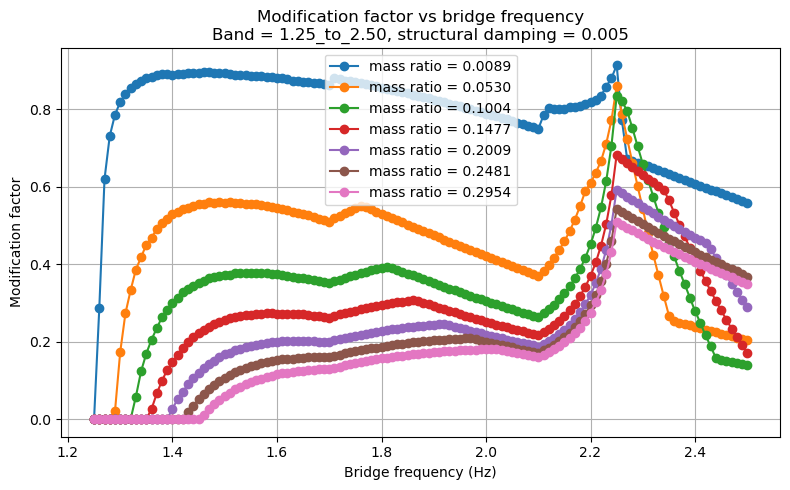

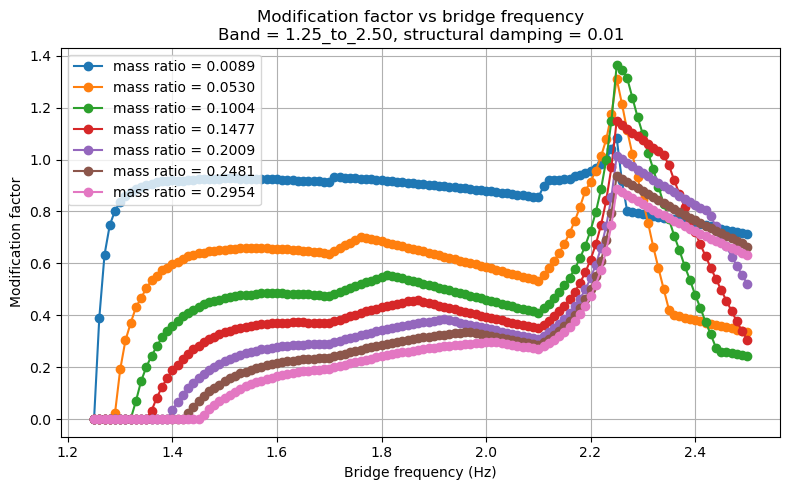

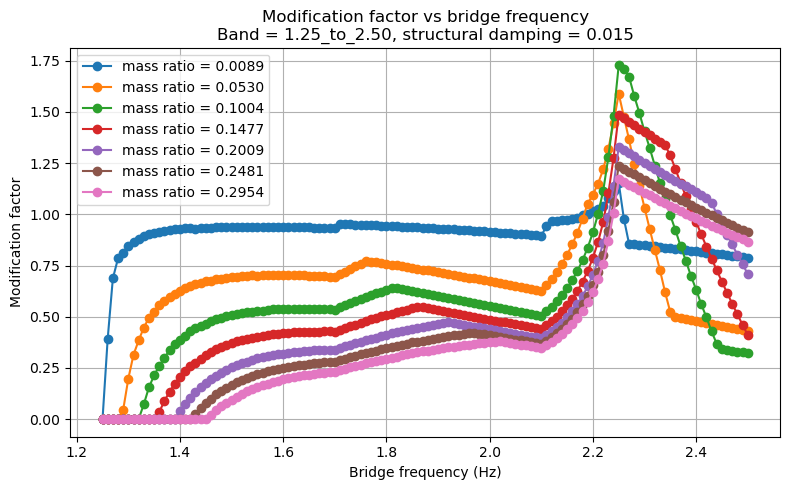

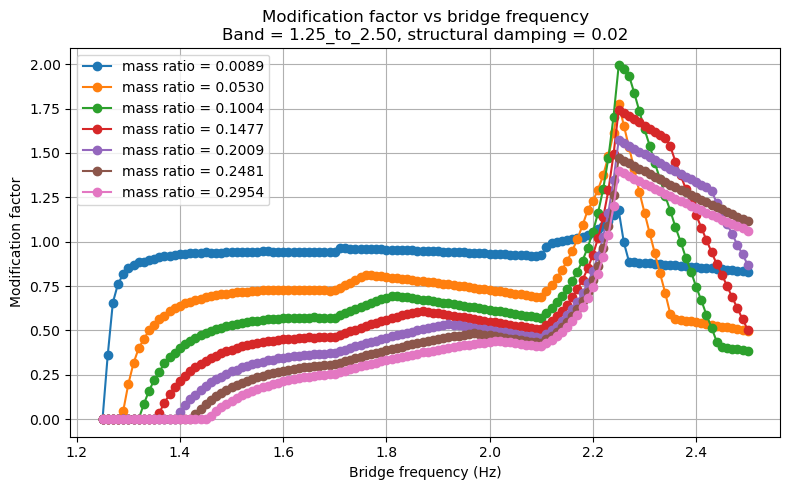

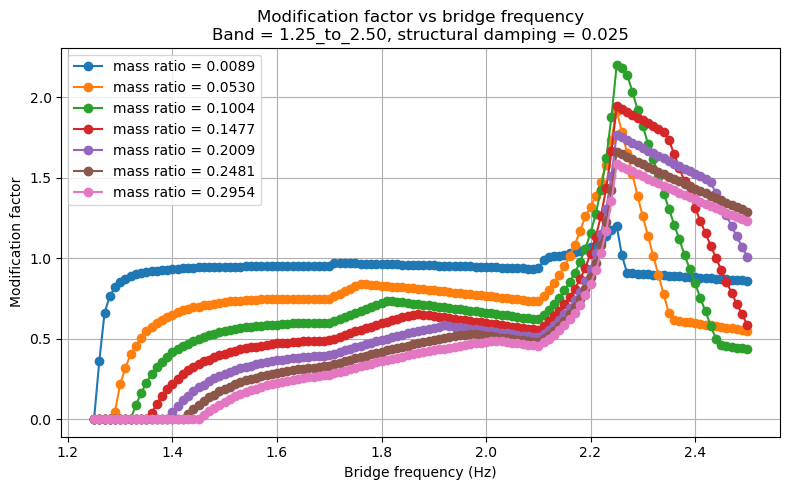

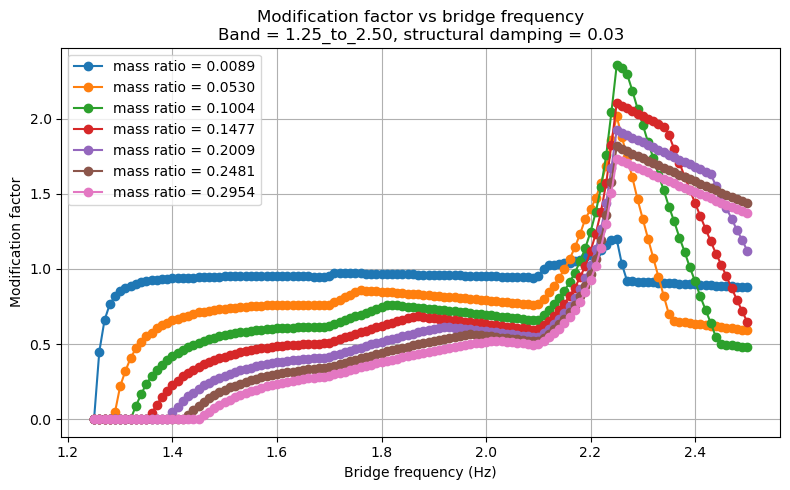

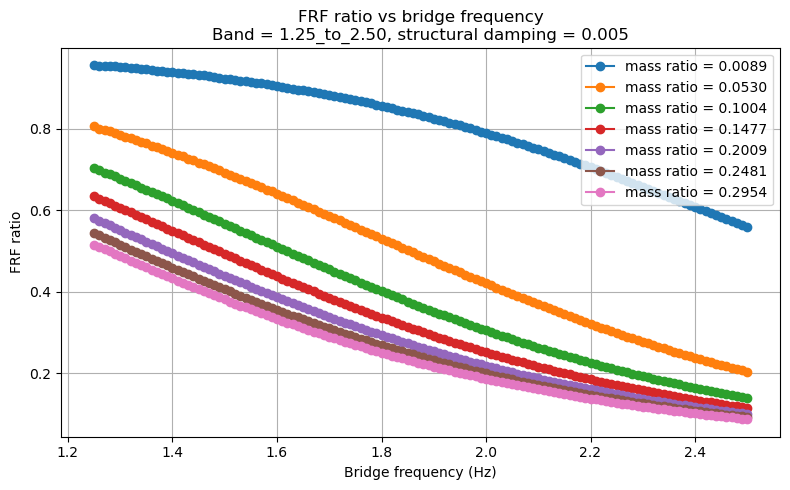

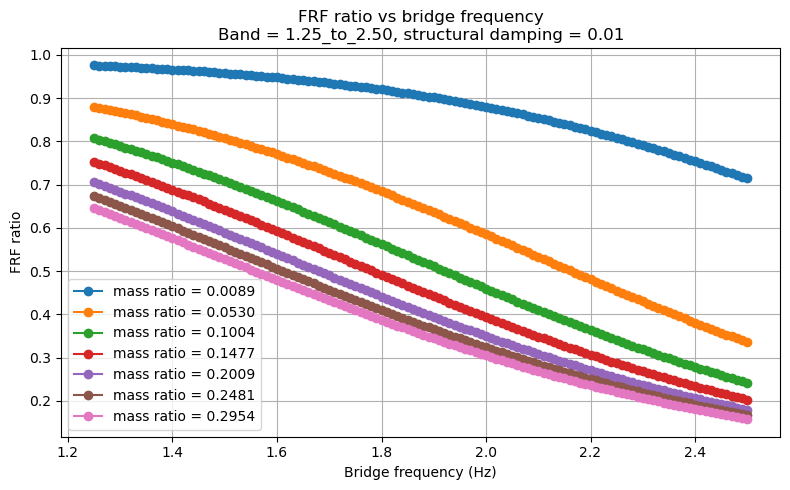

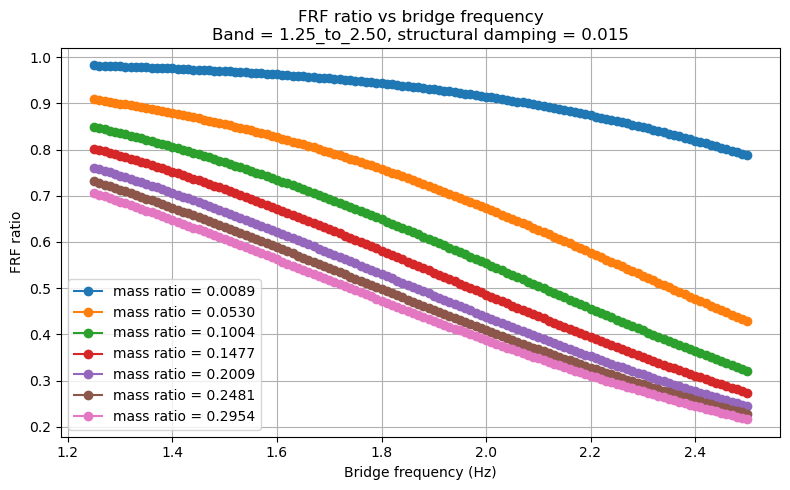

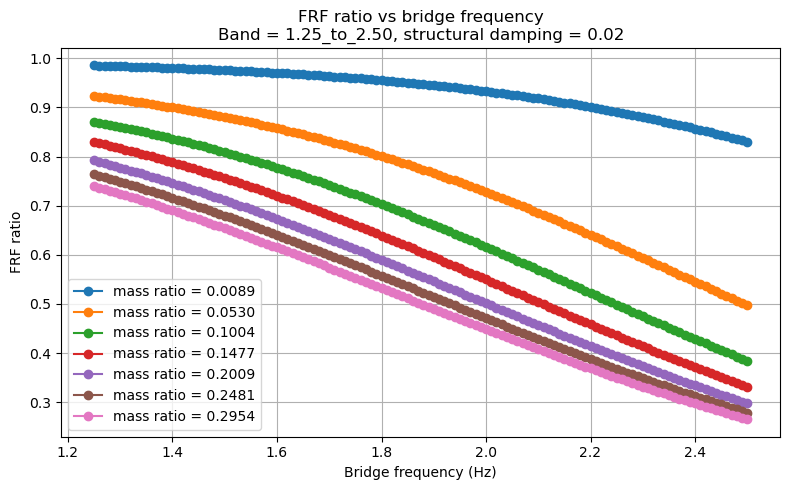

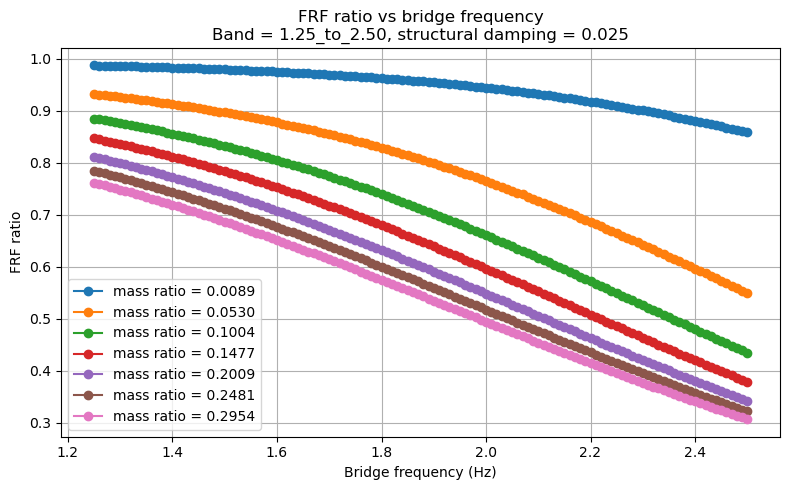

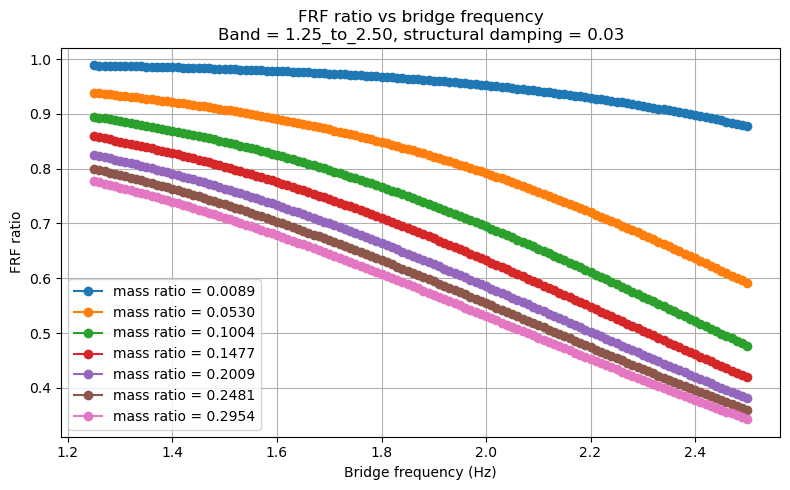

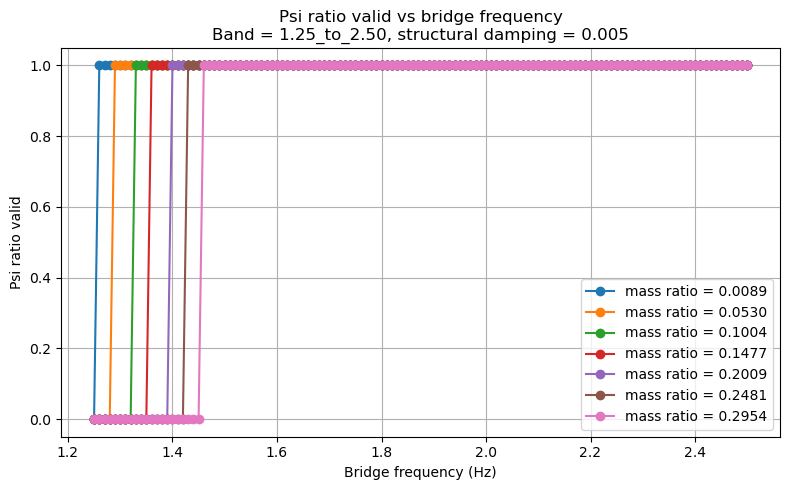

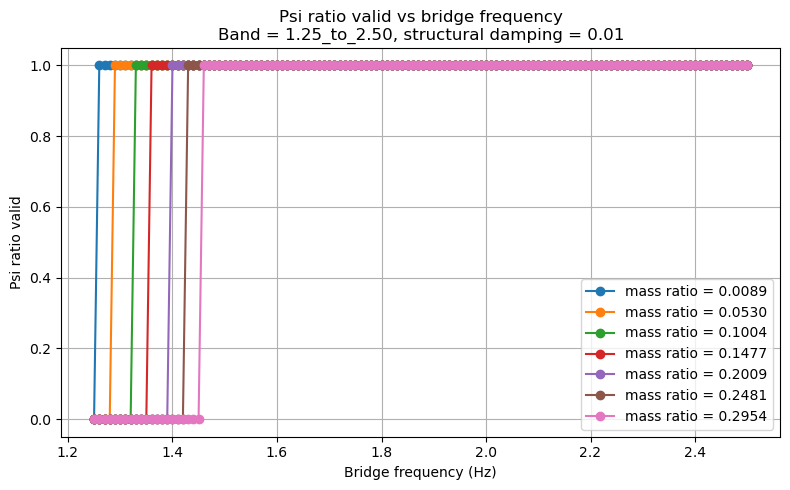

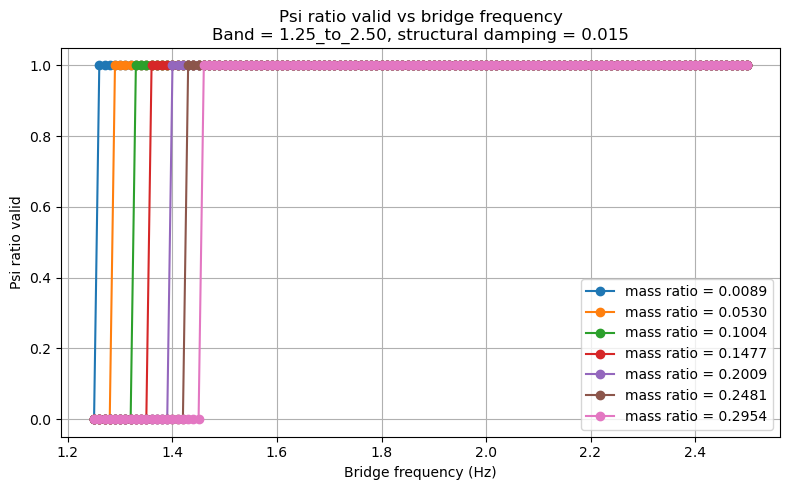

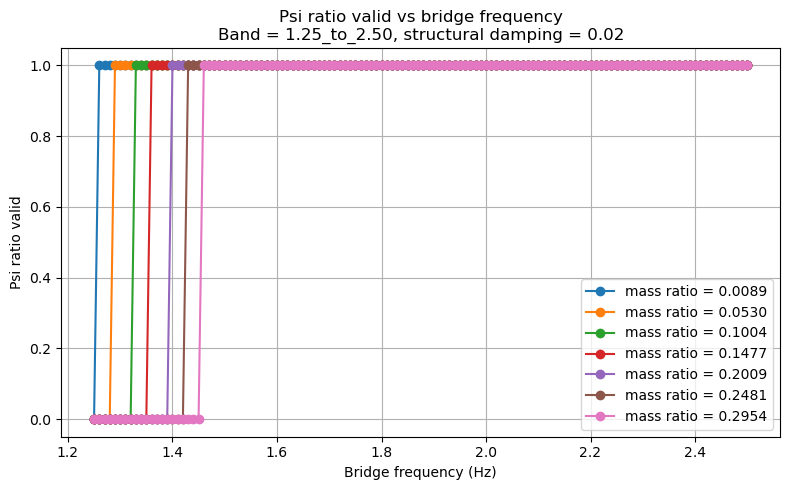

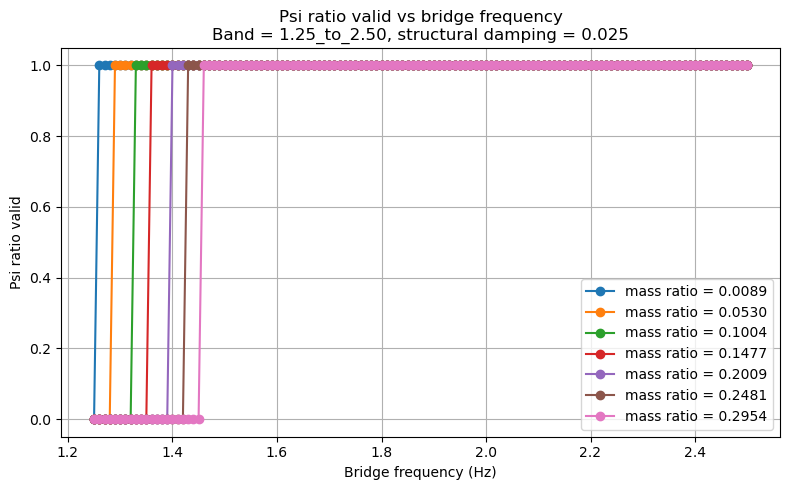

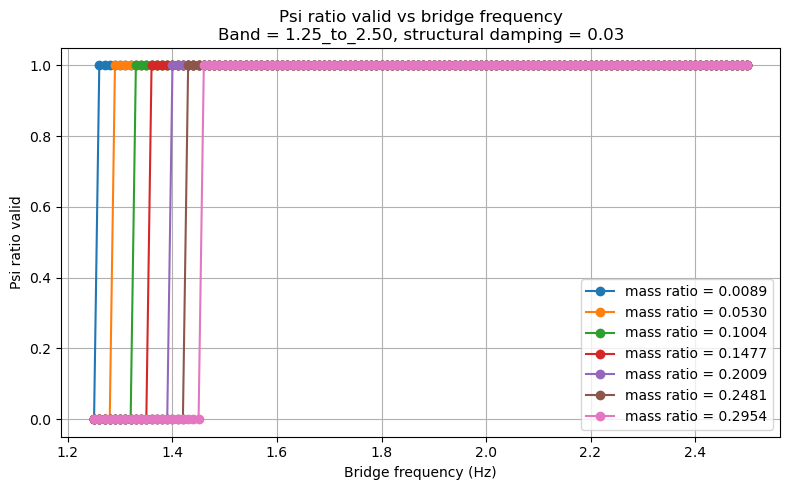

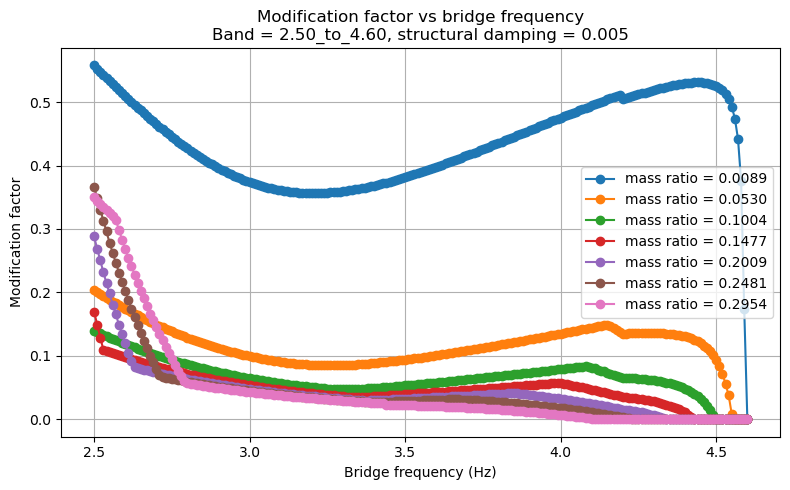

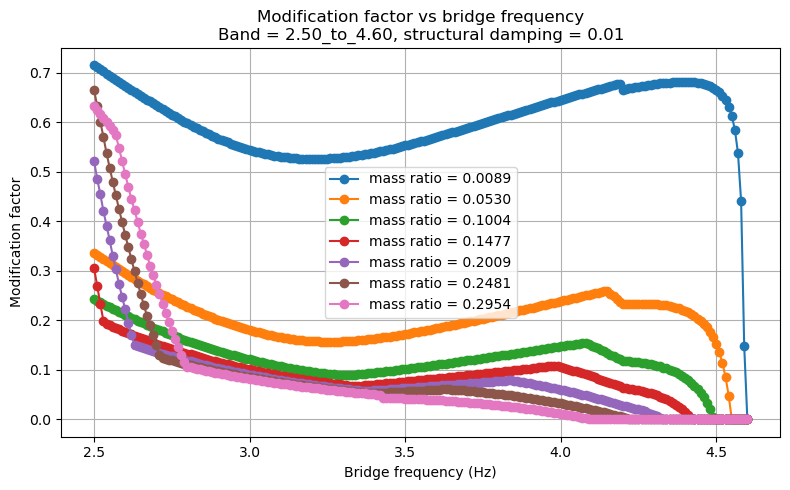

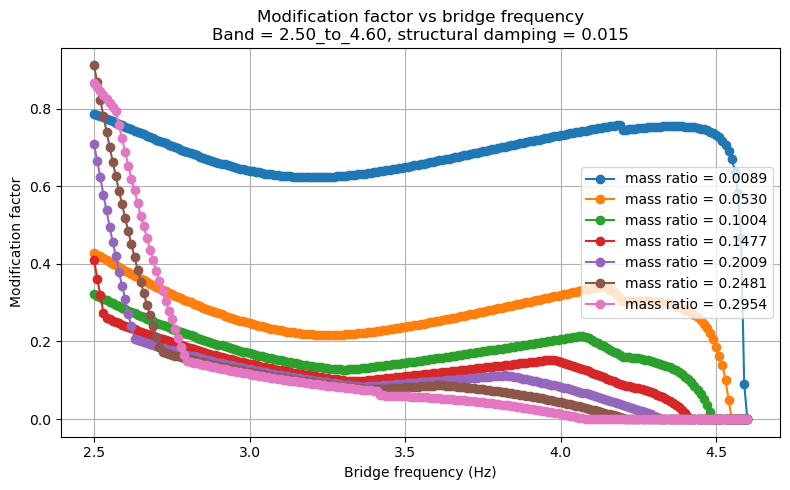

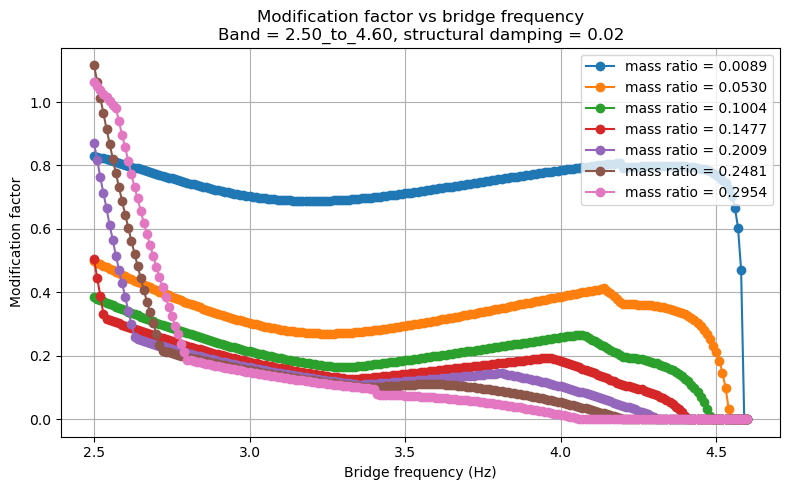

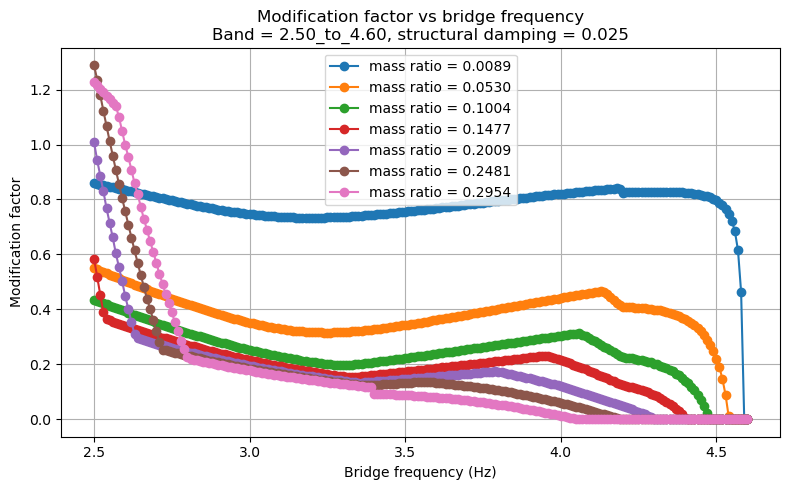

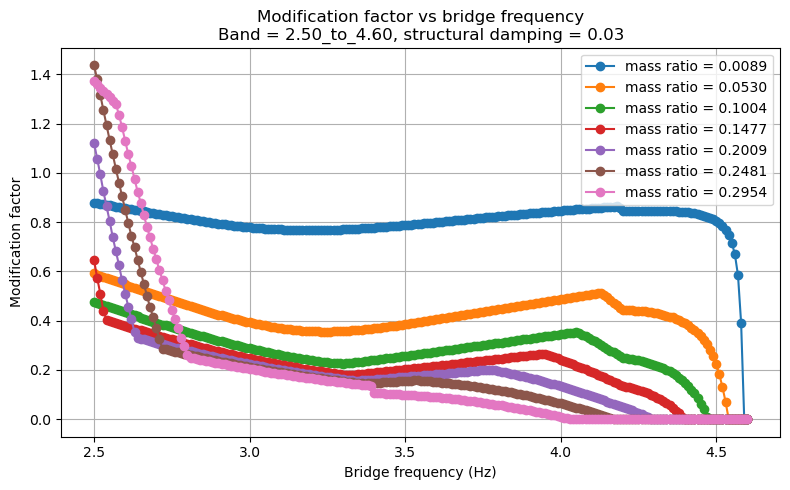

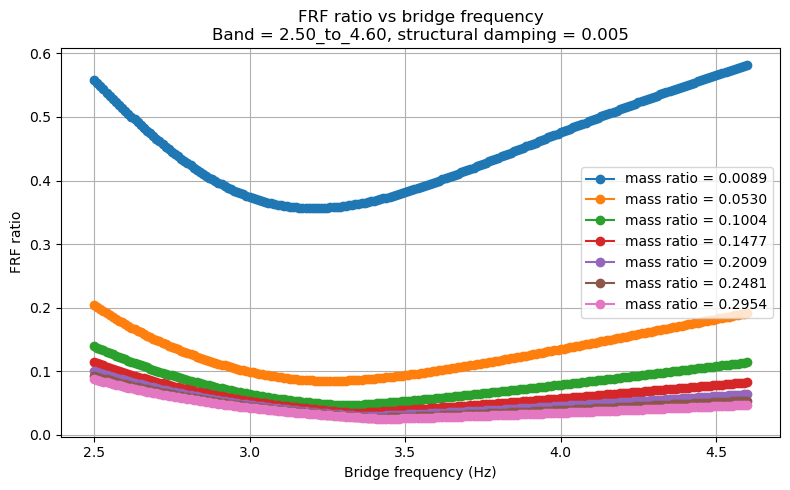

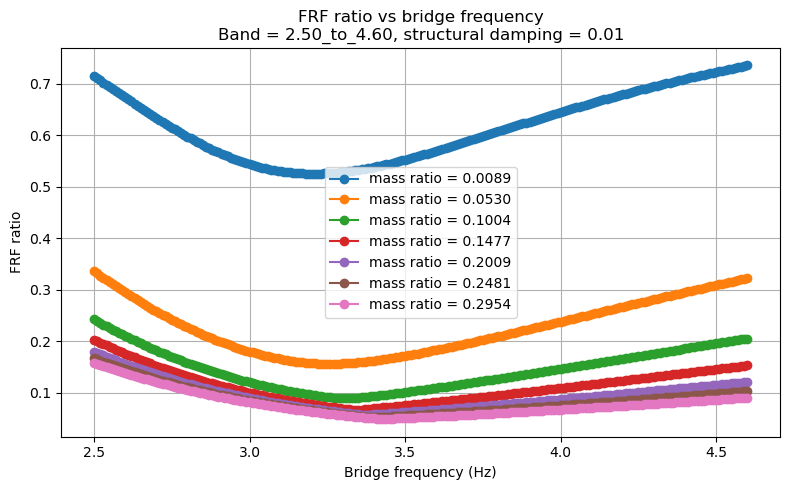

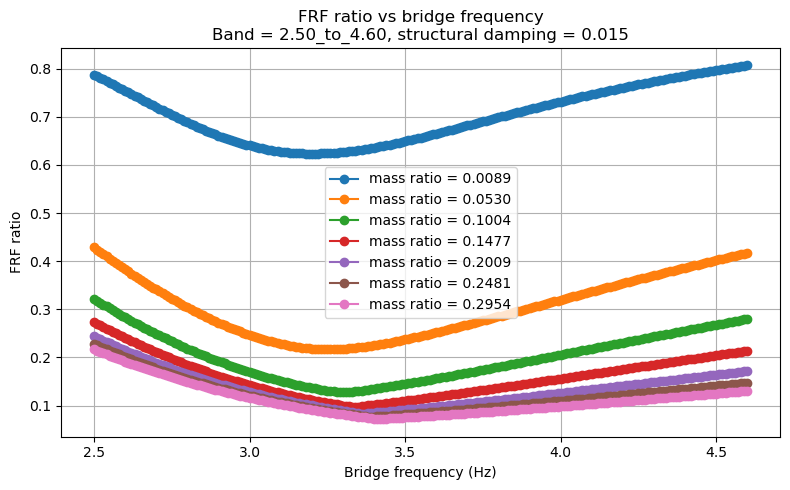

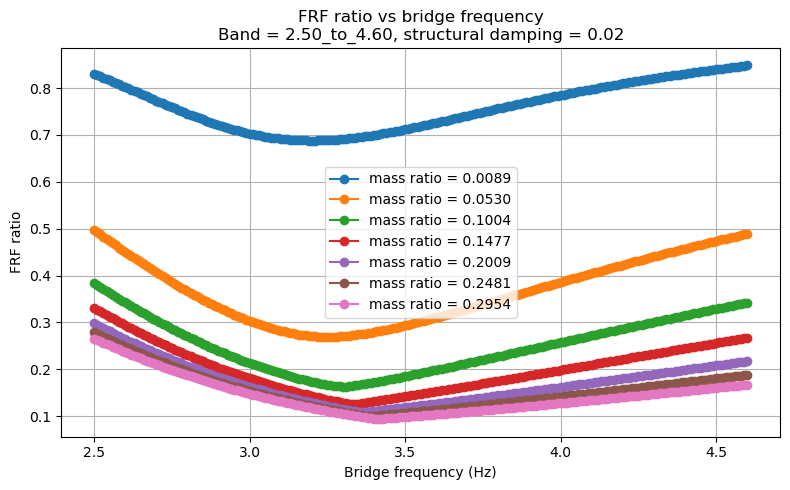

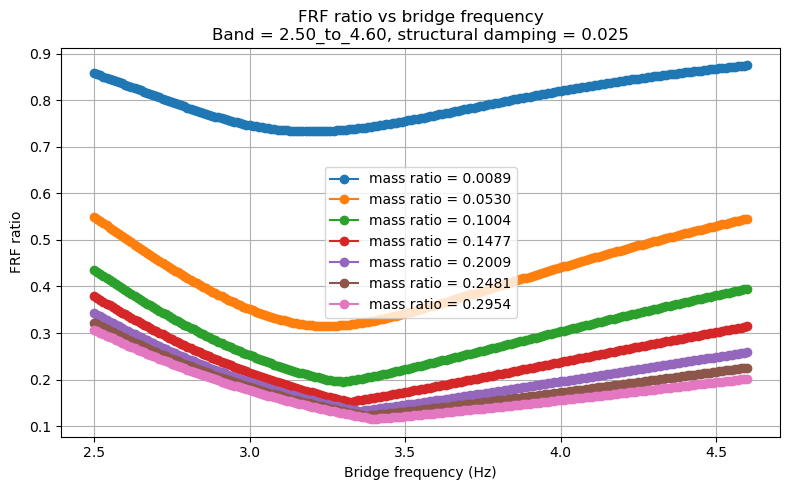

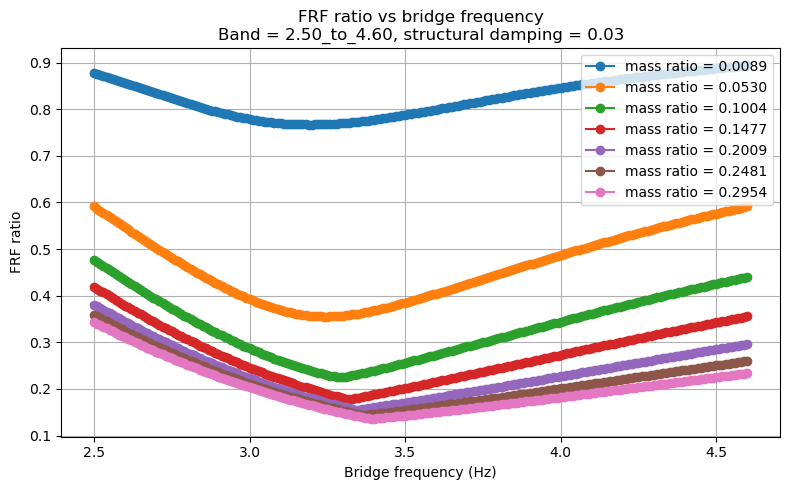

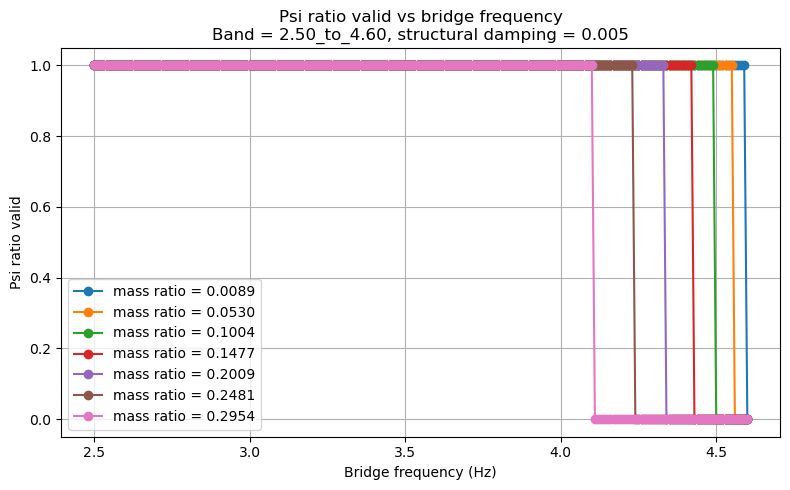

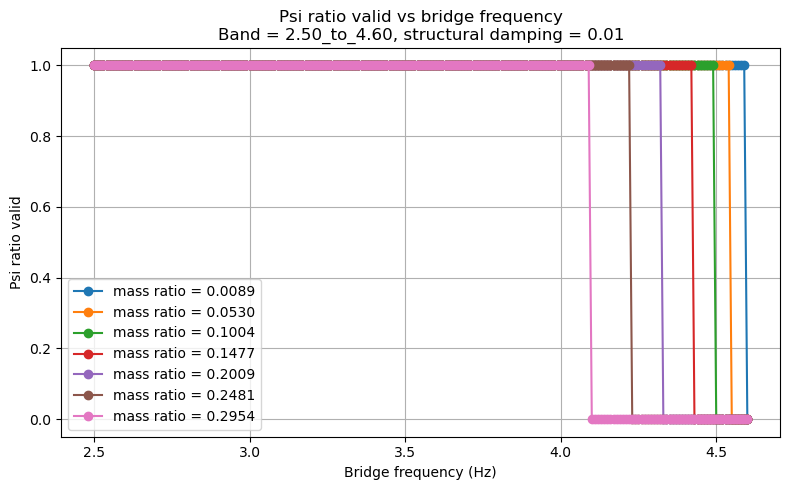

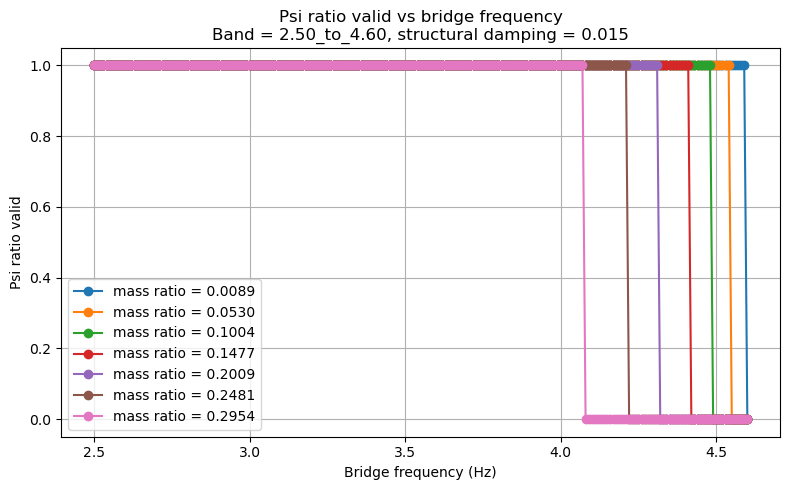

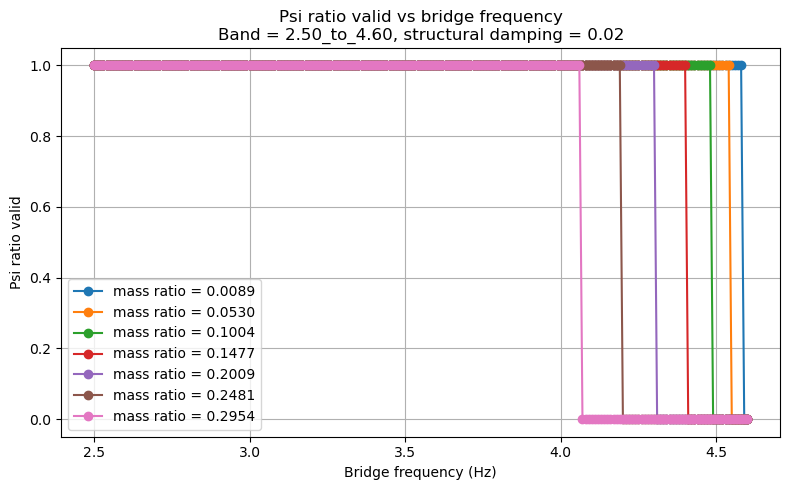

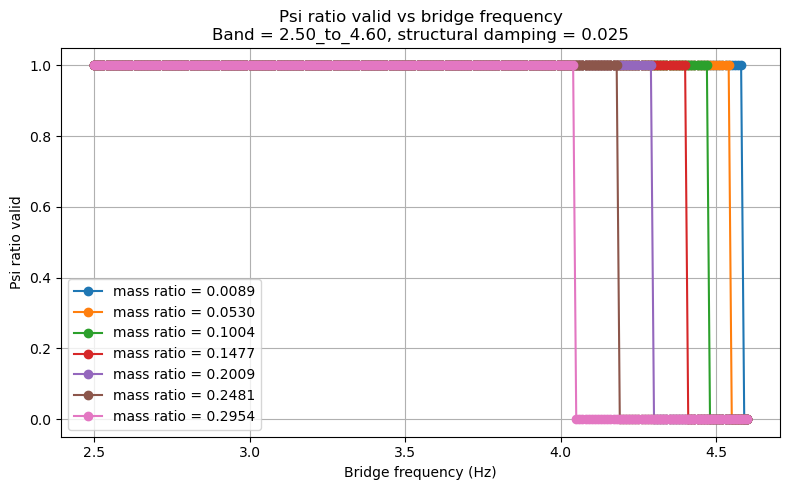

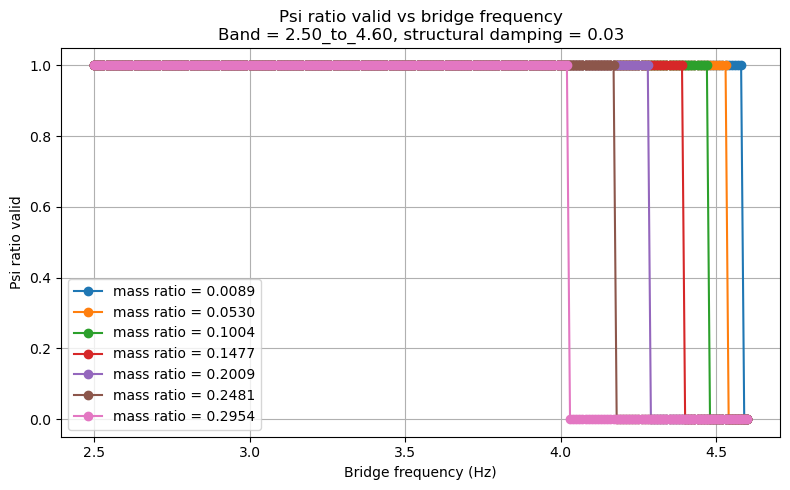

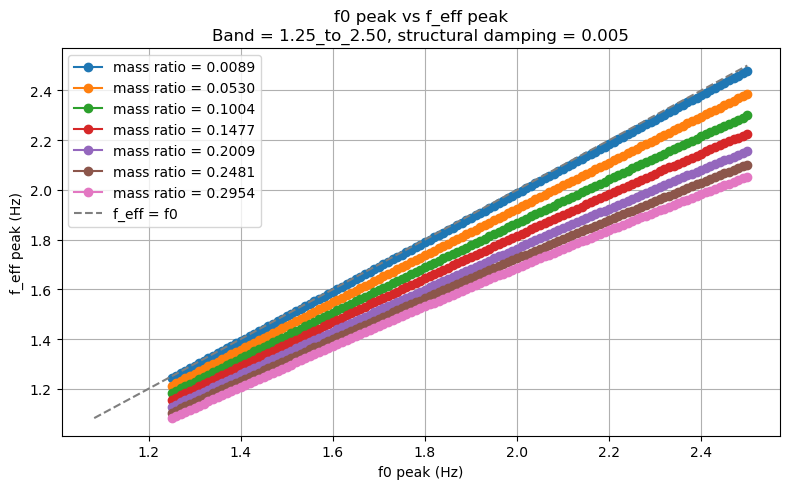

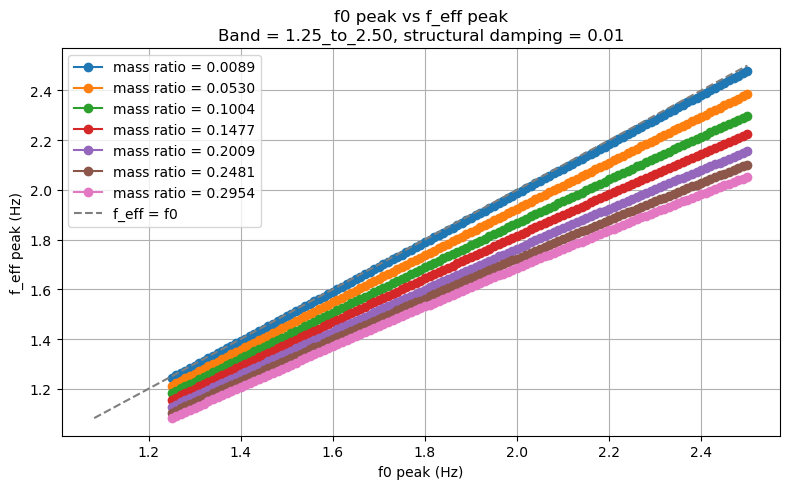

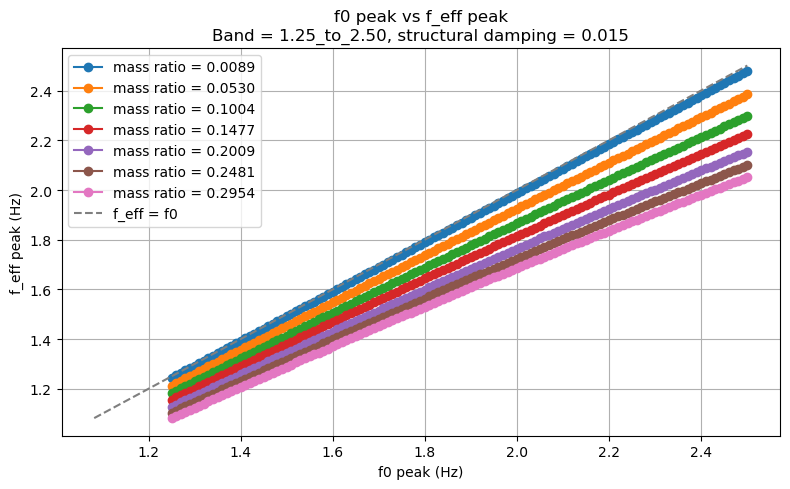

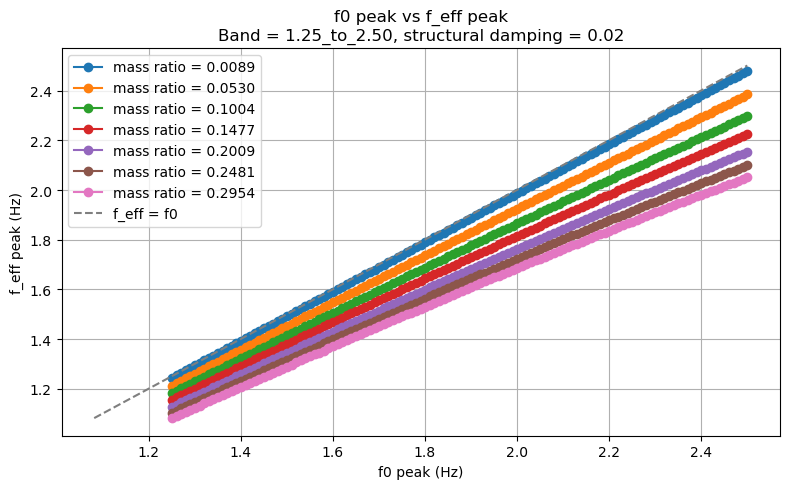

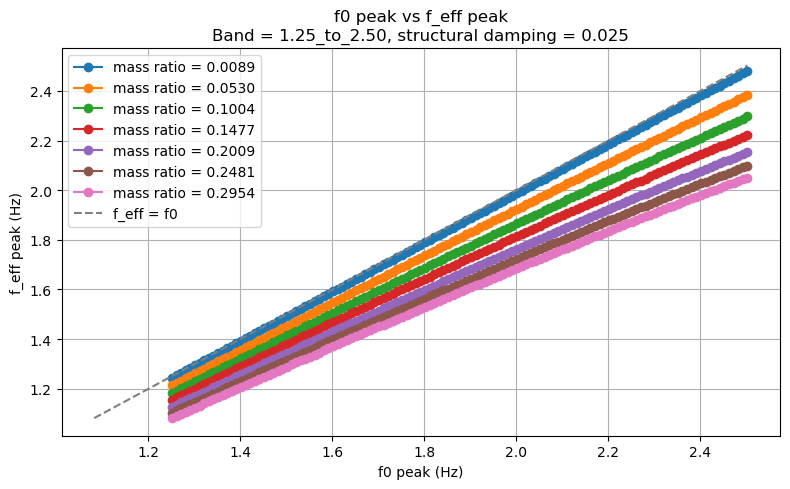

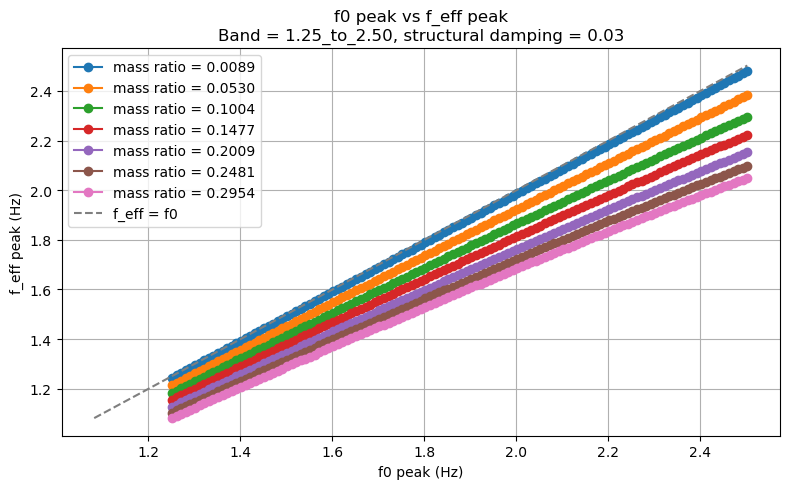

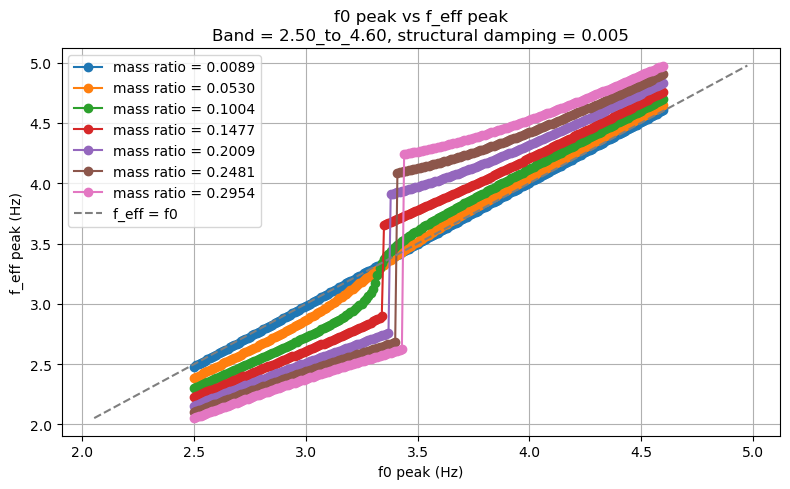

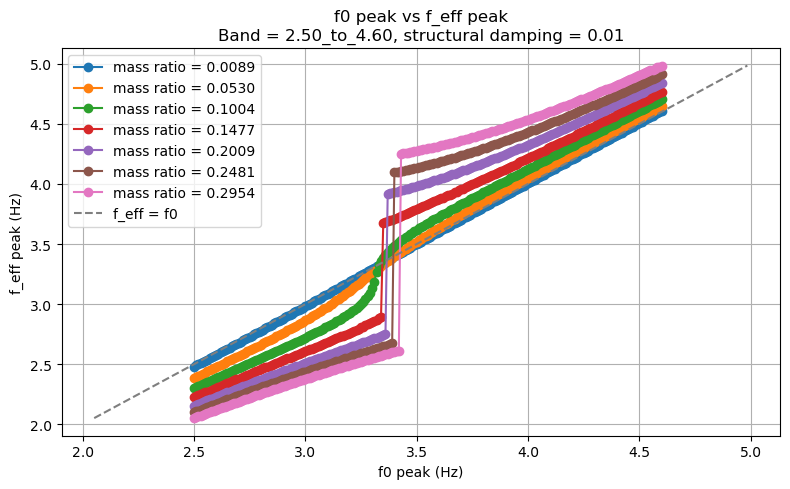

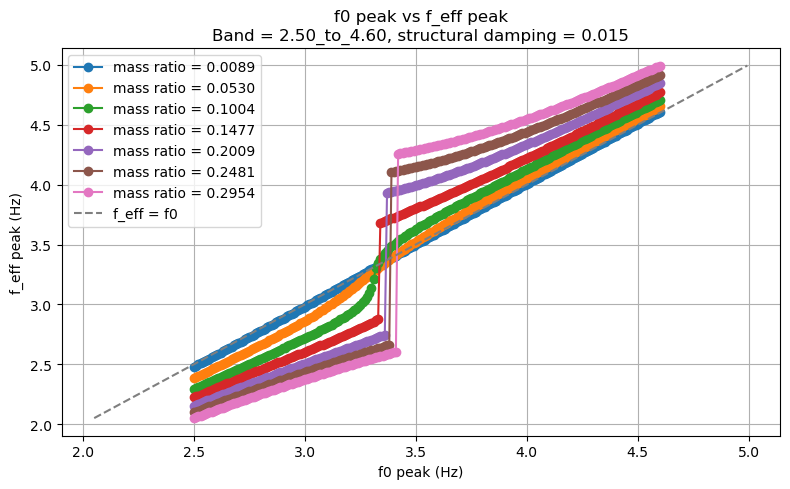

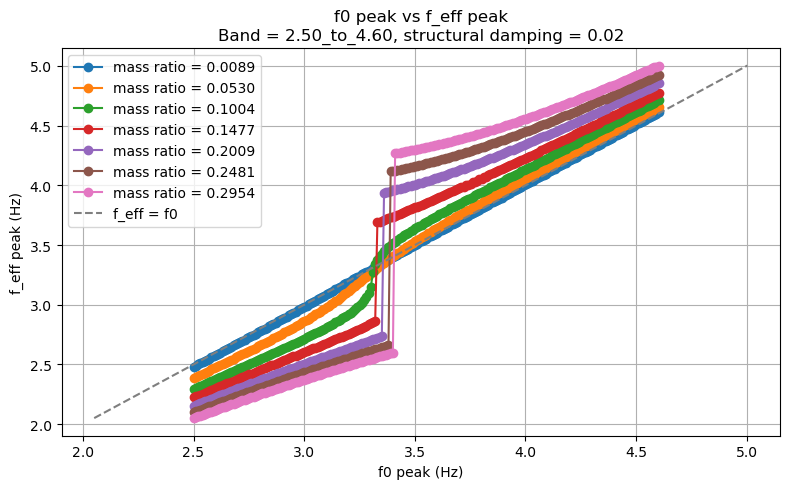

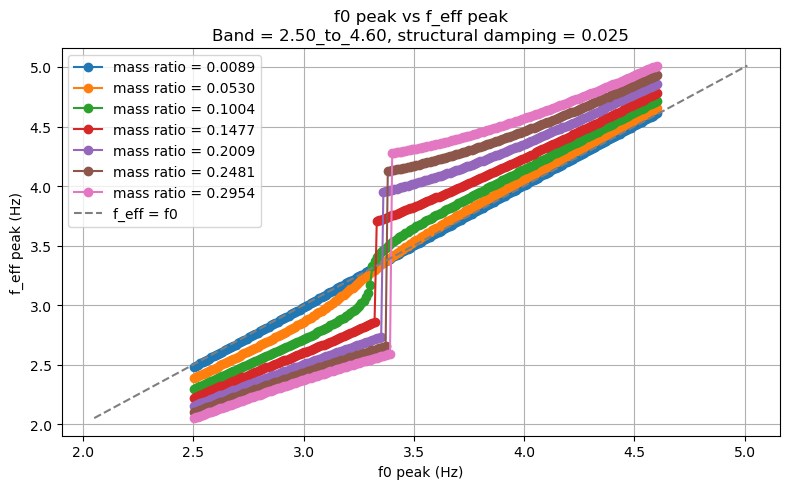

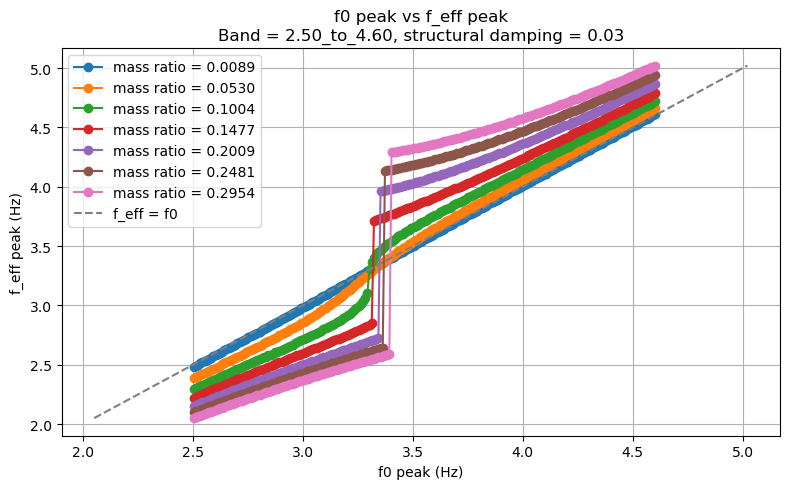

In [12]:
# -----------------------------
# MASS-RATIO LABELS
# -----------------------------
mass_ratio_label = {}

first_band = list(results_all.keys())[0]
ref_damping = damping_values[0]
ref_bf = sorted(results_all[first_band][ref_damping].keys())[0]

for density in densities:
    arr = np.array(
        results_all[first_band][ref_damping][ref_bf][density]["modalpedmass_i"]
    )
    mass_ratio_label[density] = np.mean(arr)

print("Mass-ratio labels:")
for density, mval in mass_ratio_label.items():
    print(f"density = {density:.4f}, mass ratio = {mval:.4f}")

# -----------------------------
# PLOTS: modification factor, FRF ratio, psi ratio valid
# x-axis = bridge frequency
# one graph for each structural damping and each frequency band
# -----------------------------

plot_specs = [
    ("modification_factor", "Modification factor"),
    ("frf_ratio", "FRF ratio"),
    ("psi_ratio_valid", "Psi ratio valid"),
]

for band_name in results_all.keys():

    bridge_frequencies_band = sorted(results_all[band_name][damping_values[0]].keys())

    for key, ylabel in plot_specs:

        for beamdamp in damping_values:

            plt.figure(figsize=(8, 5))

            for density in densities:

                y_vals = []

                for bf in bridge_frequencies_band:
                    arr = np.array(
                        results_all[band_name][beamdamp][bf][density][key],
                        dtype=float
                    )
                    y_vals.append(np.mean(arr))

                mval = mass_ratio_label[density]

                plt.plot(
                    bridge_frequencies_band,
                    y_vals,
                    marker="o",
                    label=f"mass ratio = {mval:.4f}"
                )

            plt.xlabel("Bridge frequency (Hz)")
            plt.ylabel(ylabel)
            plt.title(
                f"{ylabel} vs bridge frequency\n"
                f"Band = {band_name}, structural damping = {beamdamp}"
            )
            plt.grid(True)
            plt.legend()
            plt.tight_layout()
            plt.show()

# -----------------------------
# PLOT: f0_peak vs f_eff_peak
# one graph for each structural damping and each frequency band
# -----------------------------

for band_name in results_all.keys():

    bridge_frequencies_band = sorted(results_all[band_name][damping_values[0]].keys())

    for beamdamp in damping_values:

        plt.figure(figsize=(8, 5))

        all_x = []
        all_y = []

        for density in densities:

            x_vals = []
            y_vals = []

            for bf in bridge_frequencies_band:

                arr_f0 = np.array(
                    results_all[band_name][beamdamp][bf][density]["f0_peak"],
                    dtype=float
                )

                arr_feff = np.array(
                    results_all[band_name][beamdamp][bf][density]["f_eff_peak"],
                    dtype=float
                )

                x_mean = np.mean(arr_f0)
                y_mean = np.mean(arr_feff)

                x_vals.append(x_mean)
                y_vals.append(y_mean)

                all_x.append(x_mean)
                all_y.append(y_mean)

            mval = mass_ratio_label[density]

            plt.plot(
                x_vals,
                y_vals,
                marker="o",
                label=f"mass ratio = {mval:.4f}"
            )

        # optional reference line: no frequency shift
        lo = min(min(all_x), min(all_y))
        hi = max(max(all_x), max(all_y))
        plt.plot([lo, hi], [lo, hi], linestyle="--", label="f_eff = f0")

        plt.xlabel("f0 peak (Hz)")
        plt.ylabel("f_eff peak (Hz)")
        plt.title(
            f"f0 peak vs f_eff peak\n"
            f"Band = {band_name}, structural damping = {beamdamp}"
        )
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

Combining bands: ['1.25_to_2.50', '2.50_to_4.60']


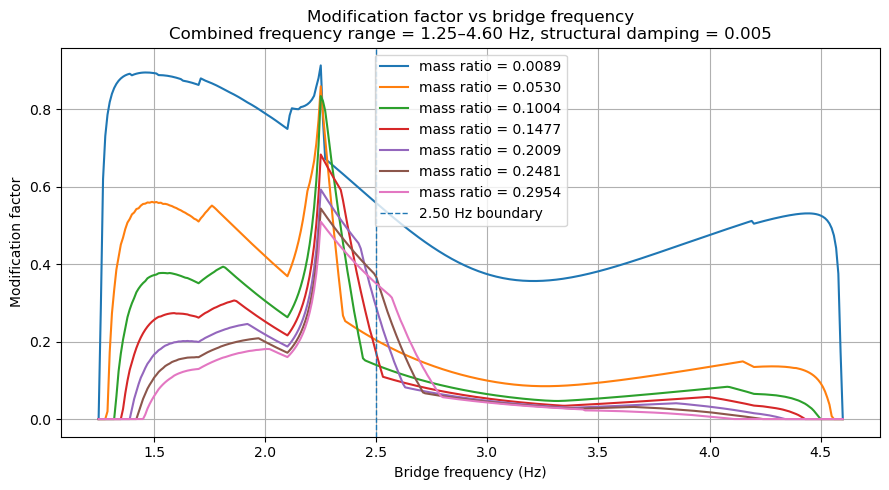

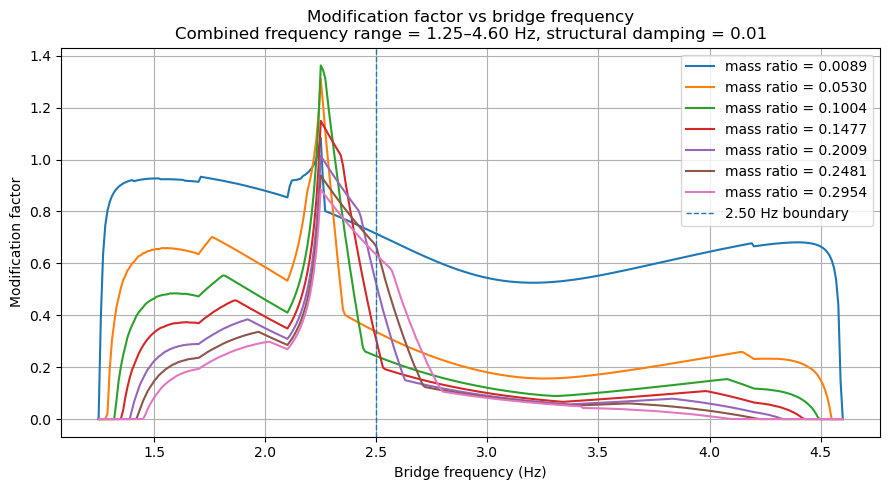

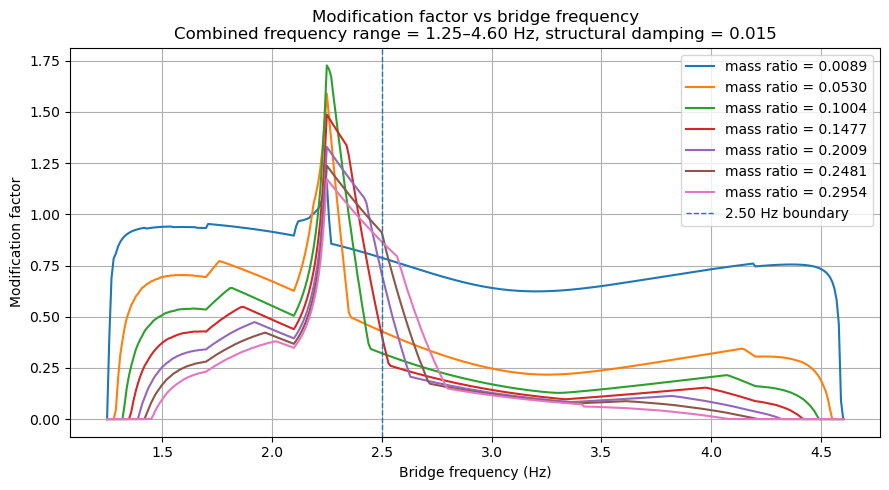

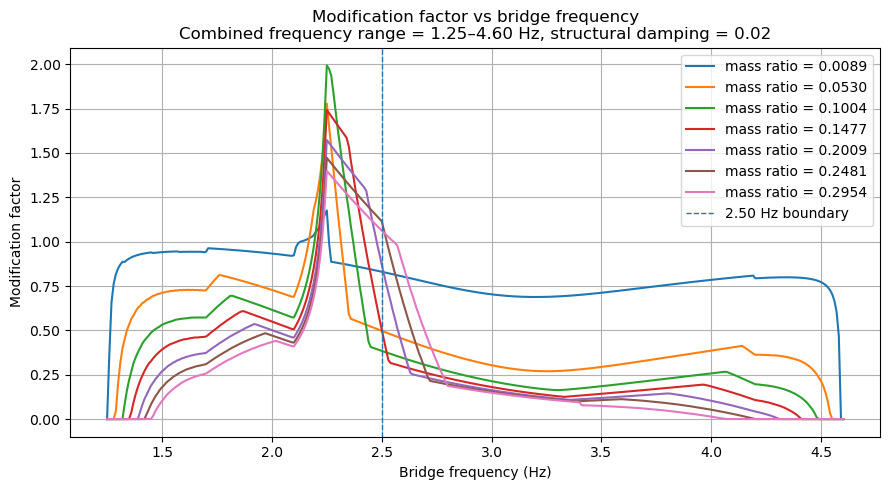

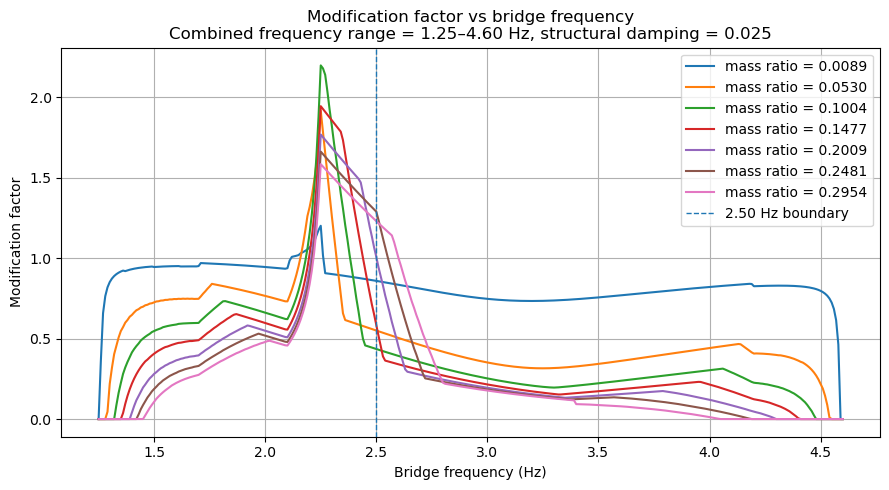

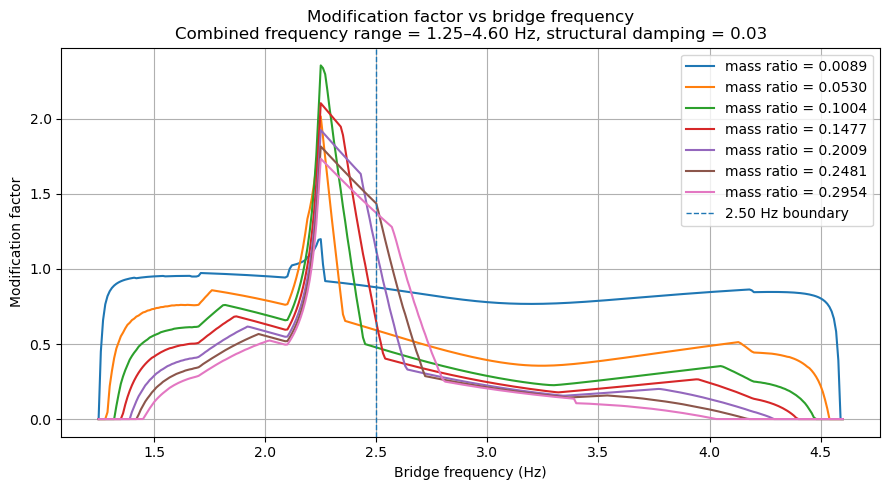

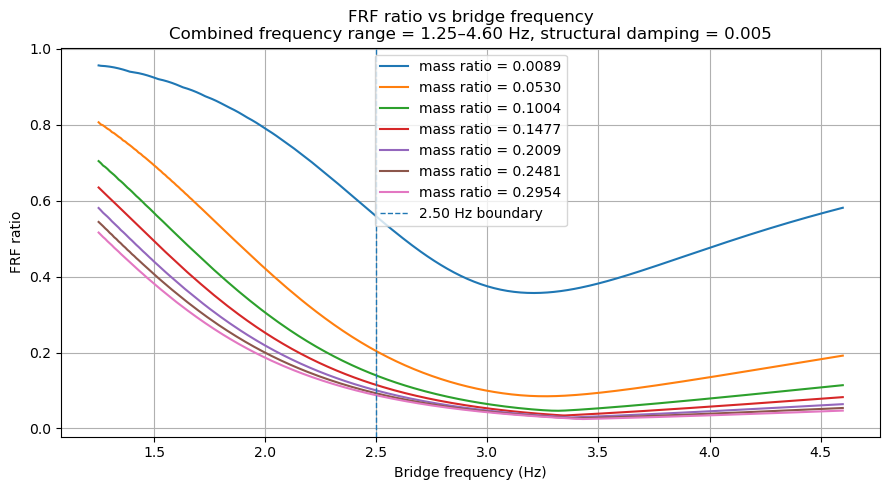

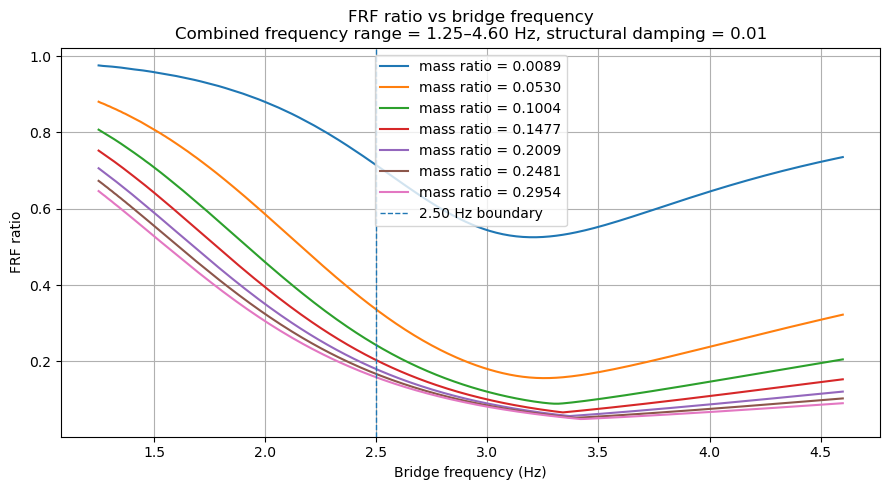

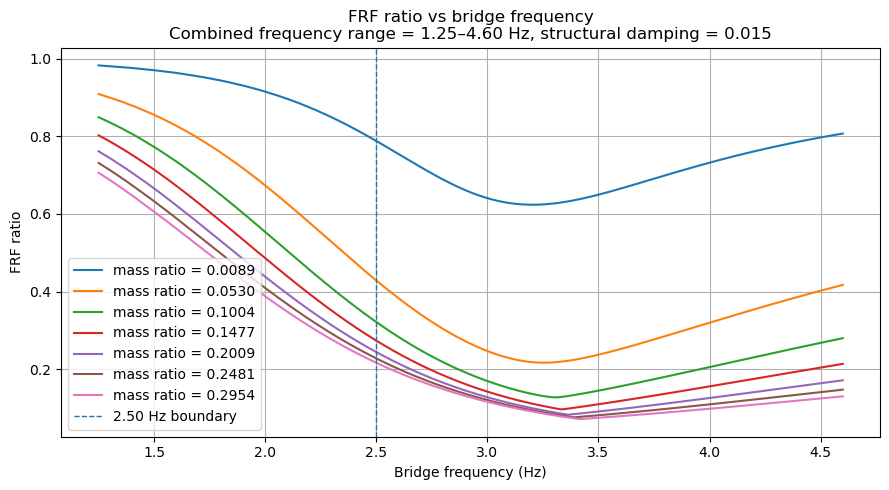

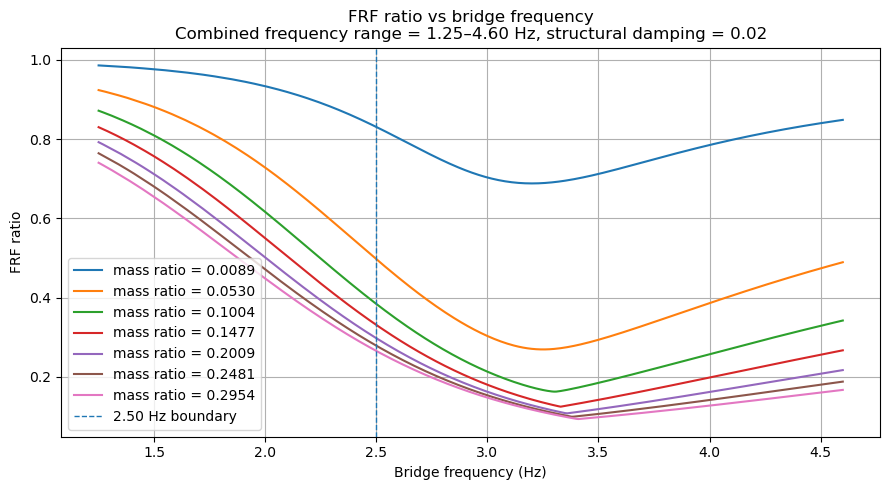

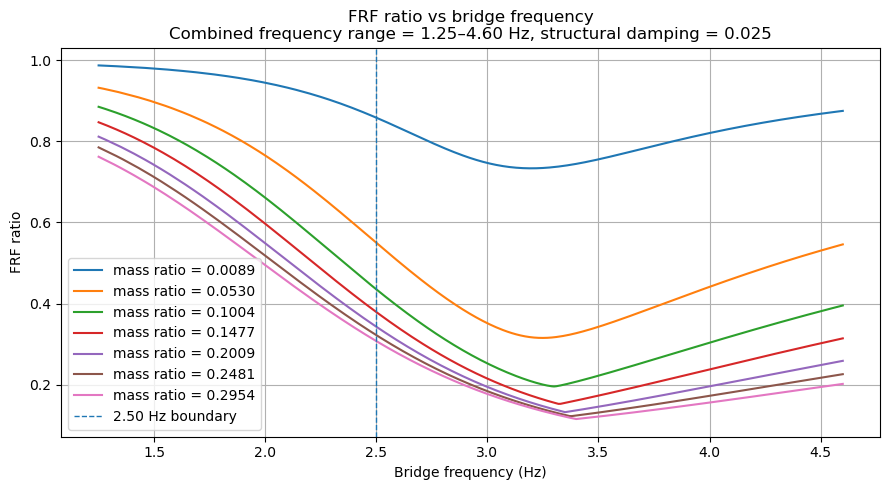

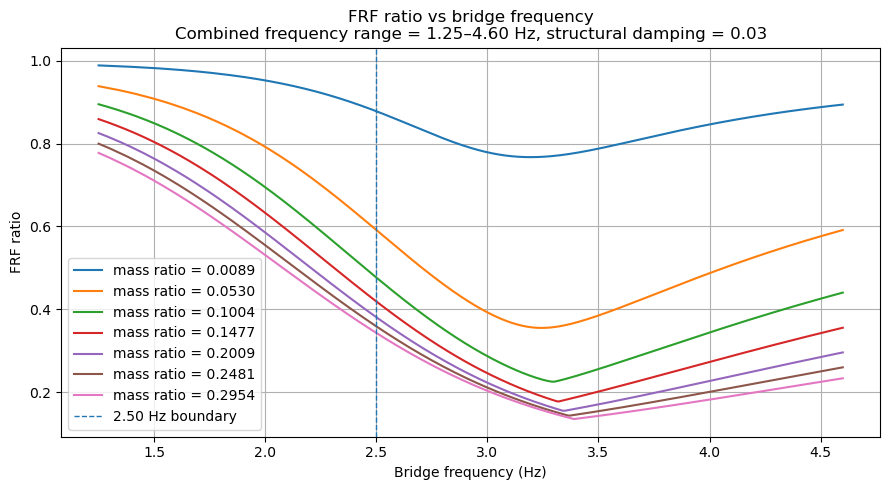

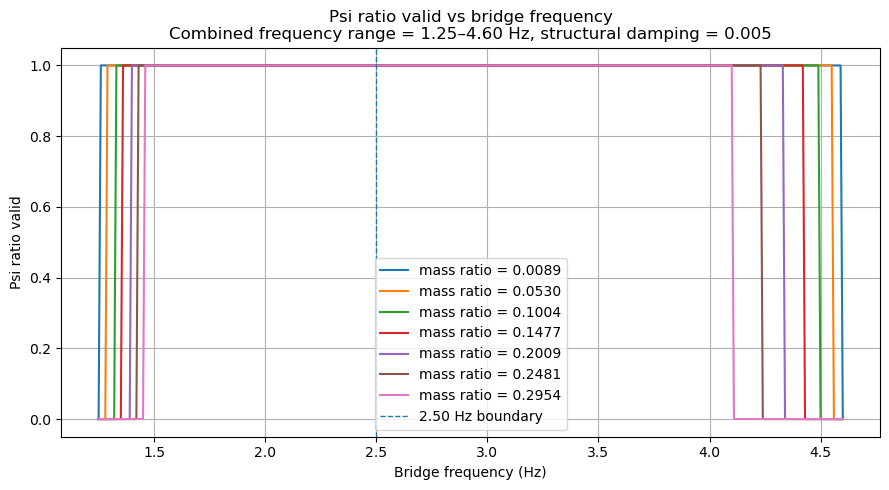

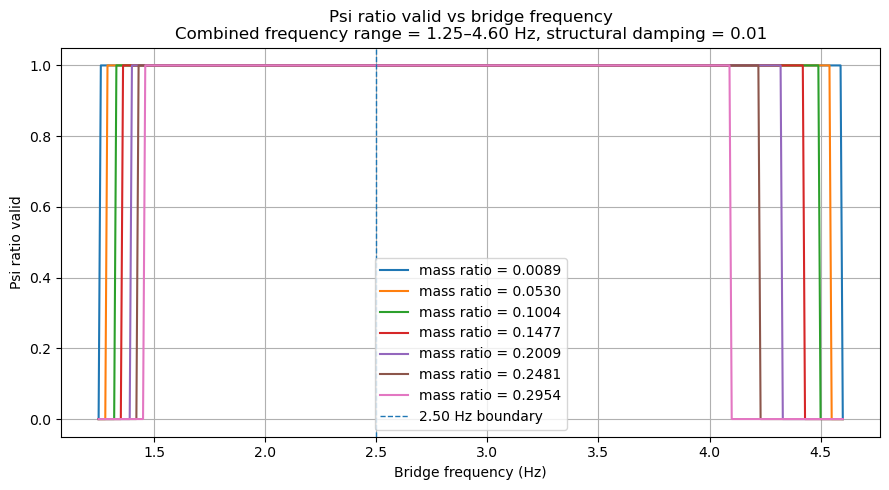

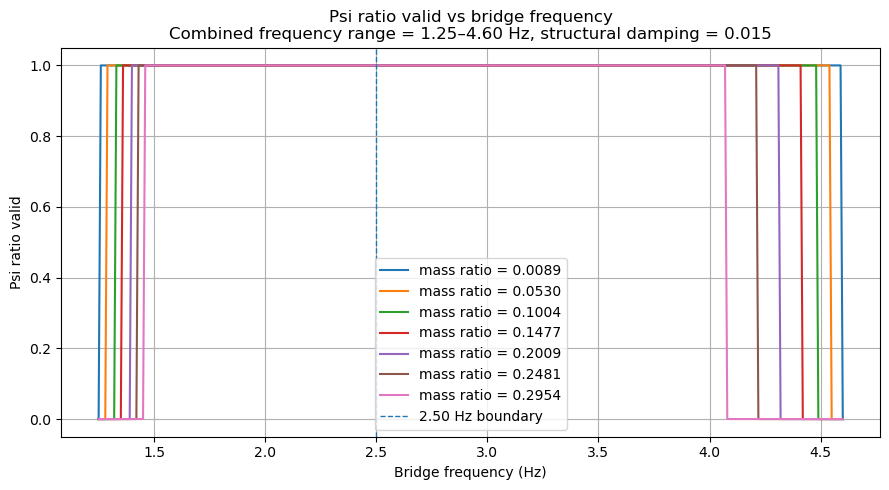

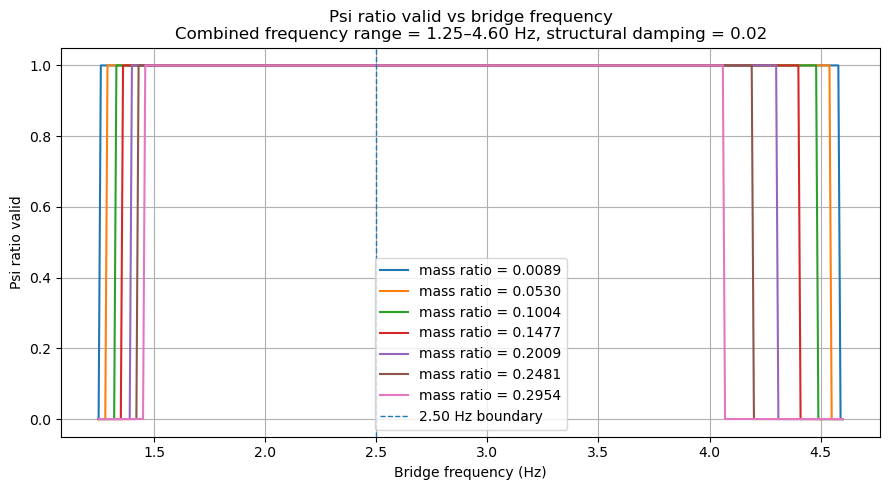

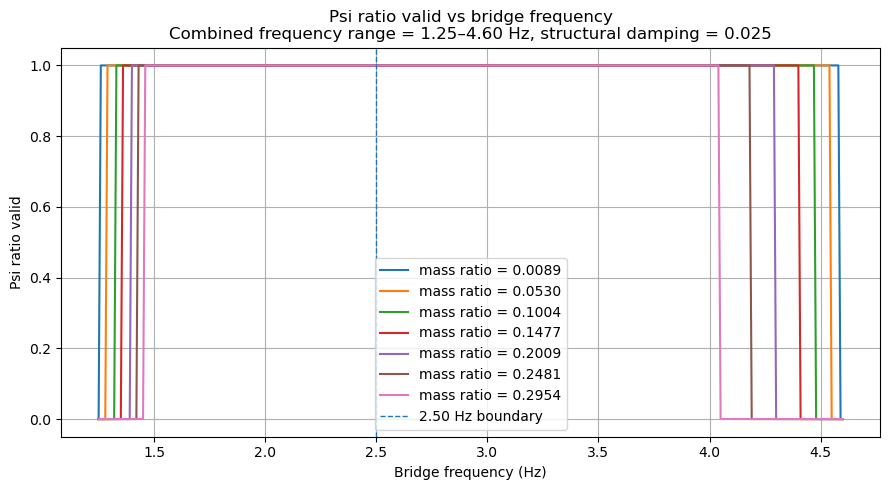

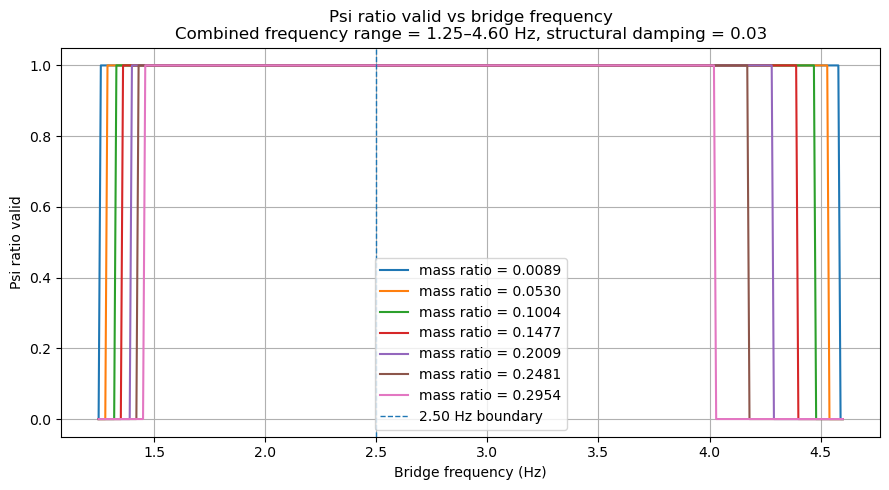

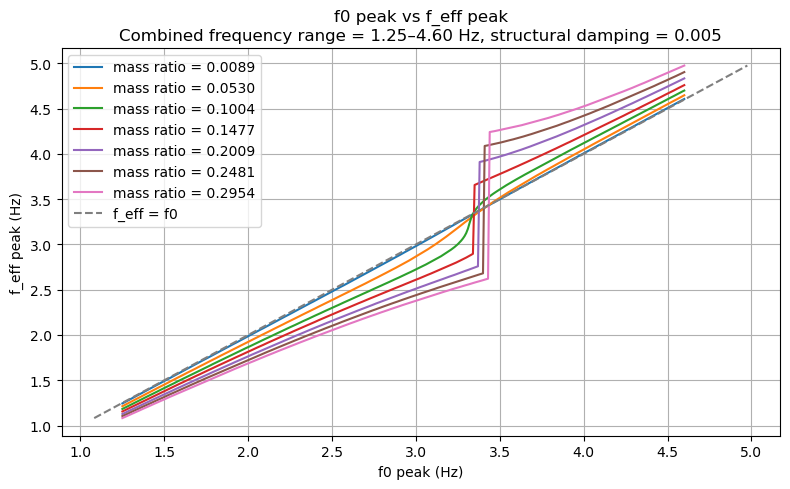

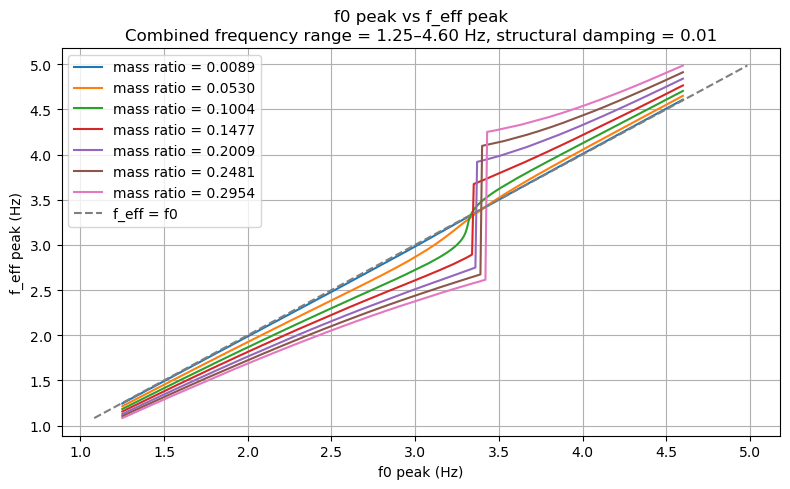

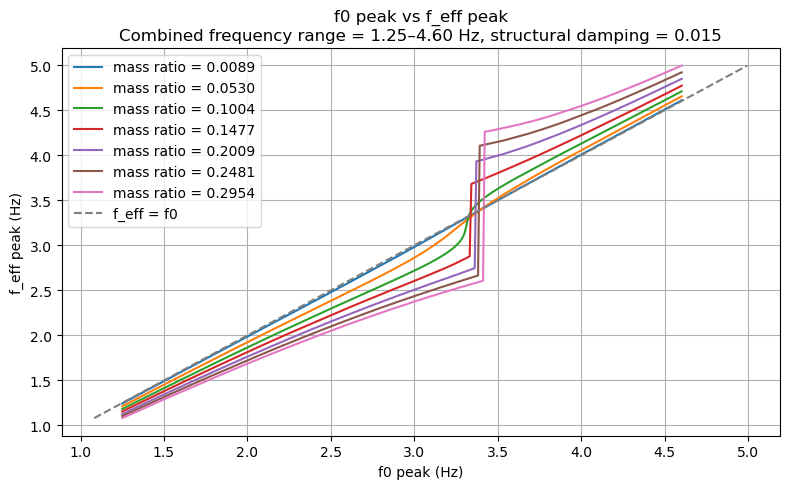

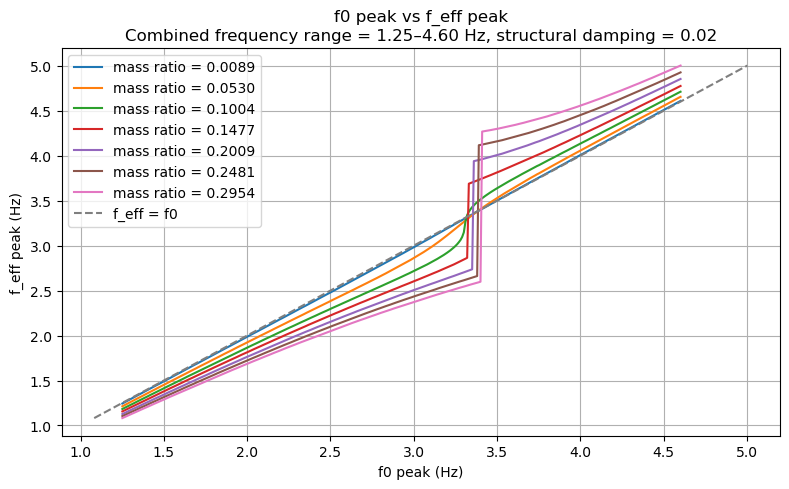

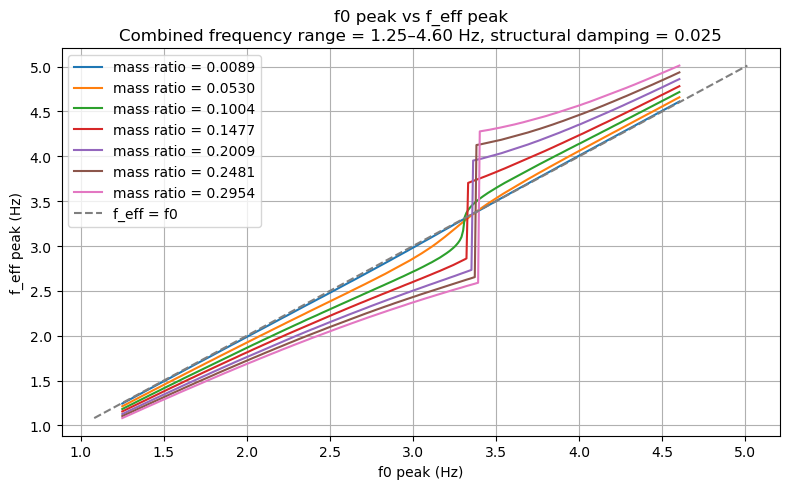

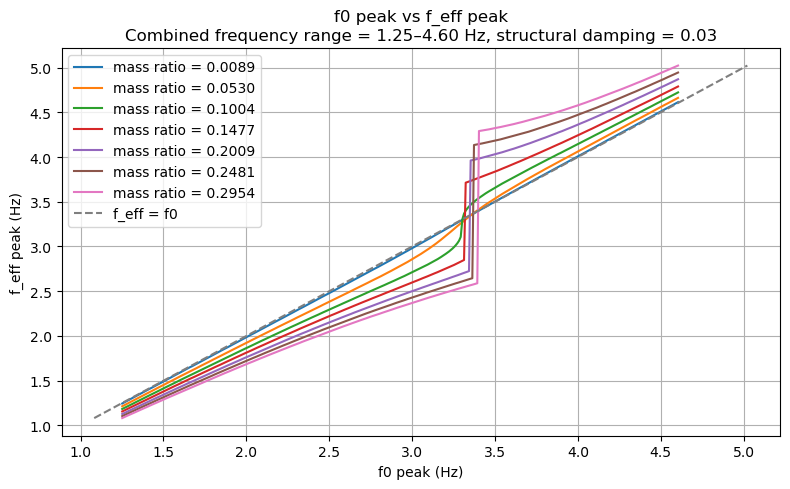

In [23]:
# -----------------------------
# COMBINE FREQUENCY BANDS FOR PLOTTING
# -----------------------------

bands_to_combine = [
    "1.25_to_2.50",
    "2.50_to_4.60",
]

# keep only bands that actually exist in results_all
bands_to_combine = [b for b in bands_to_combine if b in results_all]

print("Combining bands:", bands_to_combine)


def collect_metric_vs_frequency(results_all, bands_to_combine, beamdamp, density, key):
    """
    Collect one output quantity across multiple frequency bands.
    If the same bridge frequency appears in two bands, its values are averaged.
    """

    freq_to_values = {}

    for band_name in bands_to_combine:
        bridge_frequencies_band = sorted(results_all[band_name][beamdamp].keys())

        for bf in bridge_frequencies_band:
            arr = np.array(
                results_all[band_name][beamdamp][bf][density][key],
                dtype=float
            )

            value = np.mean(arr)

            if bf not in freq_to_values:
                freq_to_values[bf] = []

            freq_to_values[bf].append(value)

    freqs = np.array(sorted(freq_to_values.keys()))
    vals = np.array([np.mean(freq_to_values[bf]) for bf in freqs])

    return freqs, vals

# -----------------------------
# MASS-RATIO LABELS
# -----------------------------

mass_ratio_label = {}

first_band = bands_to_combine[0]
ref_damping = damping_values[0]
ref_bf = sorted(results_all[first_band][ref_damping].keys())[0]

for density in densities:
    arr = np.array(
        results_all[first_band][ref_damping][ref_bf][density]["modalpedmass_i"]
    )
    mass_ratio_label[density] = np.mean(arr)


# -----------------------------
# COMBINED PLOTS
# modification factor, FRF ratio, psi ratio valid
# x-axis = bridge frequency
# one graph for each structural damping
# -----------------------------

plot_specs = [
    ("modification_factor", "Modification factor"),
    ("frf_ratio", "FRF ratio"),
    ("psi_ratio_valid", "Psi ratio valid"),
]

for key, ylabel in plot_specs:

    for beamdamp in damping_values:

        plt.figure(figsize=(9, 5))

        for density in densities:

            x_vals, y_vals = collect_metric_vs_frequency(
                results_all,
                bands_to_combine,
                beamdamp,
                density,
                key
            )

            mval = mass_ratio_label[density]

            plt.plot(
                x_vals,
                y_vals,
                label=f"mass ratio = {mval:.4f}"
            )

        # optional: show boundary between frequency regions
        plt.axvline(2.50, linestyle="--", linewidth=1, label="2.50 Hz boundary")

        plt.xlabel("Bridge frequency (Hz)")
        plt.ylabel(ylabel)
        plt.title(
            f"{ylabel} vs bridge frequency\n"
            f"Combined frequency range = 1.25–4.60 Hz, structural damping = {beamdamp}"
        )
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

# -----------------------------
# HELPER: collect f0_peak and f_eff_peak across combined bands
# -----------------------------

def collect_f0_feff(results_all, bands_to_combine, beamdamp, density):
    """
    Collect f0_peak and f_eff_peak across multiple frequency bands.
    If the same bridge frequency appears in two bands, values are averaged.
    """

    freq_to_f0 = {}
    freq_to_feff = {}

    for band_name in bands_to_combine:
        bridge_frequencies_band = sorted(results_all[band_name][beamdamp].keys())

        for bf in bridge_frequencies_band:

            arr_f0 = np.array(
                results_all[band_name][beamdamp][bf][density]["f0_peak"],
                dtype=float
            )

            arr_feff = np.array(
                results_all[band_name][beamdamp][bf][density]["f_eff_peak"],
                dtype=float
            )

            f0_mean = np.mean(arr_f0)
            feff_mean = np.mean(arr_feff)

            if bf not in freq_to_f0:
                freq_to_f0[bf] = []
                freq_to_feff[bf] = []

            freq_to_f0[bf].append(f0_mean)
            freq_to_feff[bf].append(feff_mean)

    freqs = sorted(freq_to_f0.keys())

    x_vals = np.array([np.mean(freq_to_f0[bf]) for bf in freqs])
    y_vals = np.array([np.mean(freq_to_feff[bf]) for bf in freqs])

    return x_vals, y_vals

# -----------------------------
# COMBINED PLOT: f0_peak vs f_eff_peak
# one graph for each structural damping
# -----------------------------

for beamdamp in damping_values:

    plt.figure(figsize=(8, 5))

    all_x = []
    all_y = []

    for density in densities:

        x_vals, y_vals = collect_f0_feff(
            results_all,
            bands_to_combine,
            beamdamp,
            density
        )

        all_x.extend(x_vals)
        all_y.extend(y_vals)

        mval = mass_ratio_label[density]

        plt.plot(
            x_vals,
            y_vals,
            label=f"mass ratio = {mval:.4f}"
        )

    # reference line: no frequency shift
    lo = min(min(all_x), min(all_y))
    hi = max(max(all_x), max(all_y))
    plt.plot([lo, hi], [lo, hi], linestyle="--", label="f_eff = f0")

    plt.xlabel("f0 peak (Hz)")
    plt.ylabel("f_eff peak (Hz)")
    plt.title(
        f"f0 peak vs f_eff peak\n"
        f"Combined frequency range = 1.25–4.60 Hz, structural damping = {beamdamp}"
    )
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [14]:
# -----------------------------
# SAVE RESULTS AS PKL
# -----------------------------
import pickle

save_data = {
    "results_all": results_all,
    "frequency_bands": frequency_bands,
    "densities": densities,
    "damping_values": damping_values,
    "NUM_SIMULATIONS": NUM_SIMULATIONS,
    "NUM_PROCESSES": NUM_PROCESSES,
    "length": length,
    "width": width,
    "peddamp": peddamp,
    "pedBodyF": pedBodyF,
    "Linearmass": Linearmass,
}

pkl_filename = "New_modification_factor_results.pkl"

with open(pkl_filename, "wb") as f:
    pickle.dump(save_data, f, protocol=pickle.HIGHEST_PROTOCOL)

print(f"Saved results to {pkl_filename}")

Saved results to New_modification_factor_results.pkl


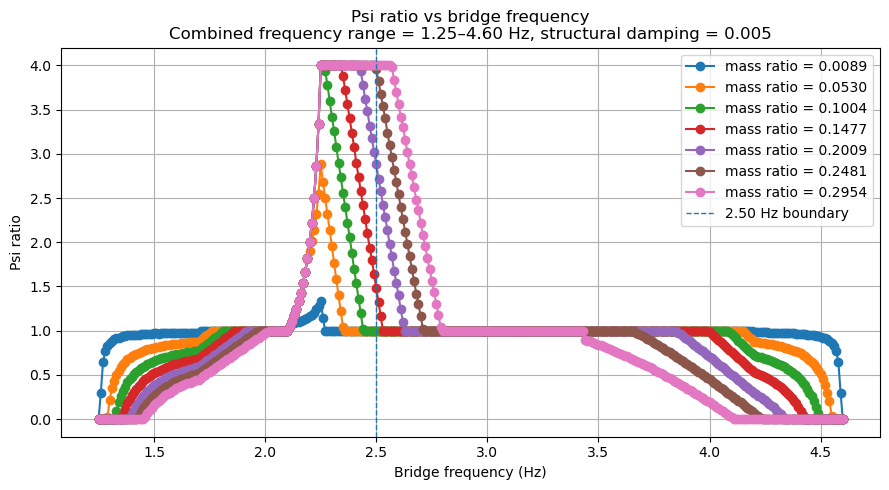

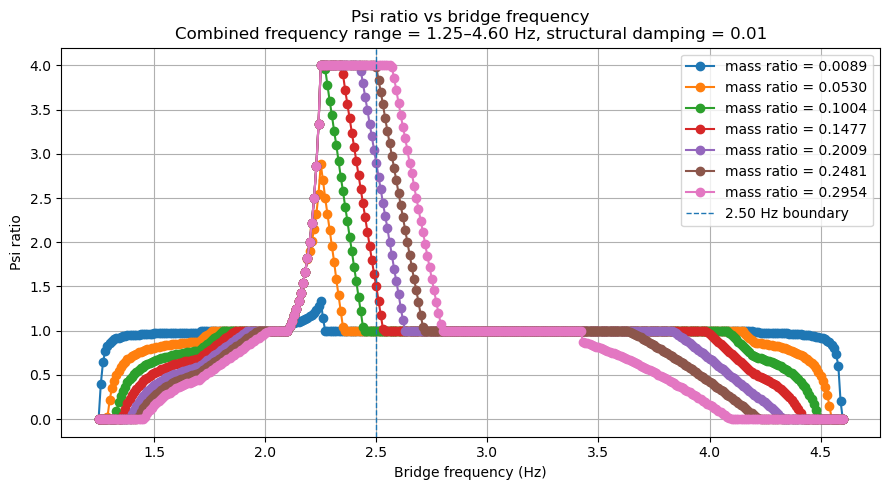

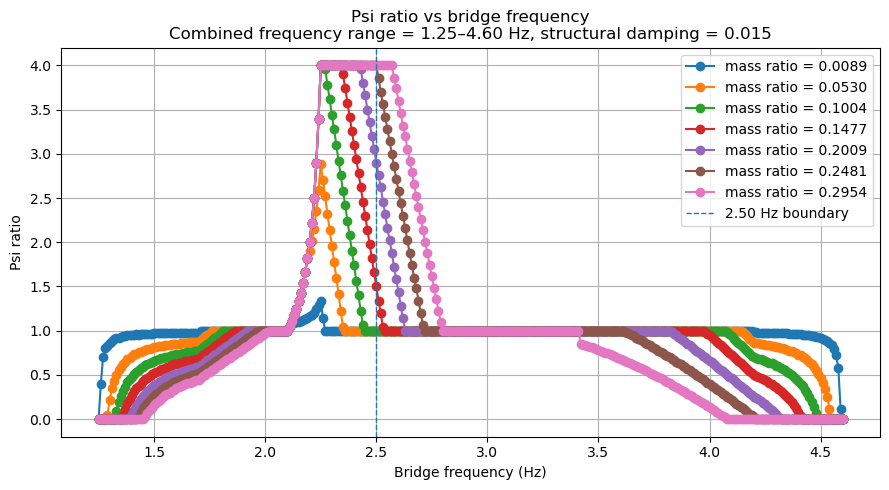

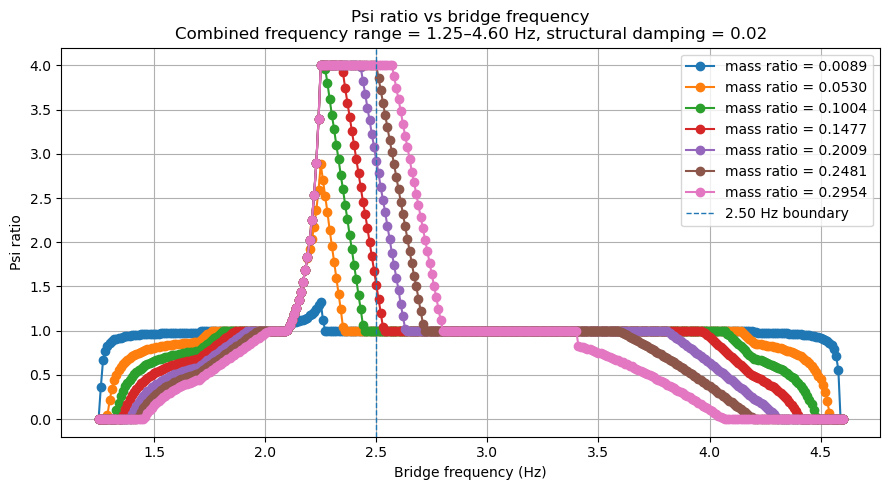

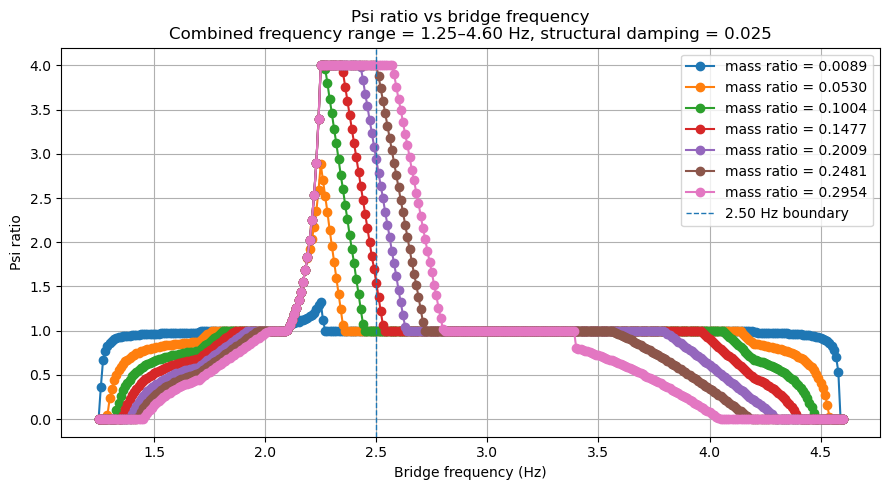

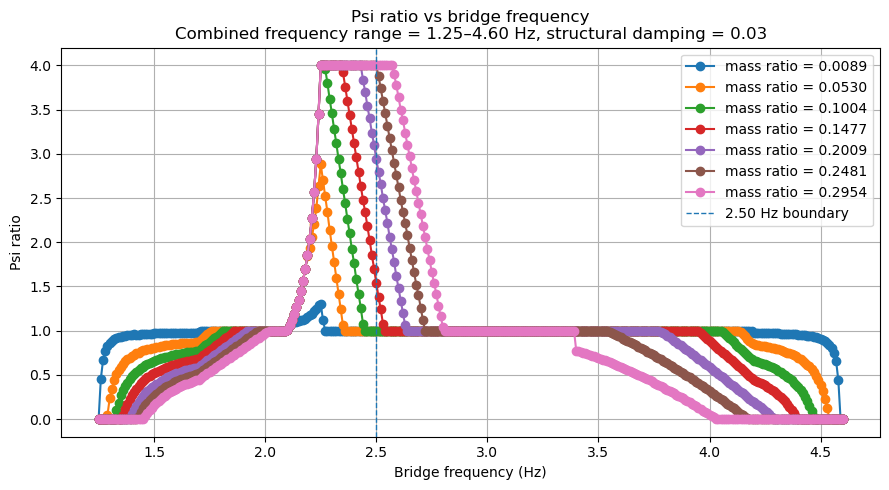

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from pedestrian import psi_w_h1

# -----------------------------
# BANDS TO COMBINE
# -----------------------------
bands_to_combine = [
    "1.25_to_2.50",
    "2.50_to_4.60",
]

bands_to_combine = [b for b in bands_to_combine if b in results_all]

# -----------------------------
# MASS-RATIO LABELS
# -----------------------------
mass_ratio_label = {}

first_band = bands_to_combine[0]
ref_damping = damping_values[0]
ref_bf = sorted(results_all[first_band][ref_damping].keys())[0]

for density in densities:
    arr = np.array(
        results_all[first_band][ref_damping][ref_bf][density]["modalpedmass_i"],
        dtype=float
    )
    mass_ratio_label[density] = np.mean(arr)


# -----------------------------
# HELPER: collect psi ratio vs bridge frequency
# -----------------------------
def collect_psi_ratio_vs_frequency(results_all, bands_to_combine, beamdamp, density):
    freq_to_values = {}

    eps = 1e-12

    for band_name in bands_to_combine:

        bridge_frequencies_band = sorted(results_all[band_name][beamdamp].keys())

        for bf in bridge_frequencies_band:

            arr_f0 = np.array(
                results_all[band_name][beamdamp][bf][density]["f0_peak"],
                dtype=float
            )

            arr_feff = np.array(
                results_all[band_name][beamdamp][bf][density]["f_eff_peak"],
                dtype=float
            )

            psi_ratios_this_bf = []

            for f0_peak, f_eff_peak in zip(arr_f0, arr_feff):

                psi_0 = float(psi_w_h1(f0_peak))
                psi_eff = float(psi_w_h1(f_eff_peak))

                if (psi_0 > eps) and (psi_eff > eps):
                    psi_ratio = psi_eff / psi_0
                else:
                    psi_ratio = 0.0

                psi_ratios_this_bf.append(psi_ratio)

            psi_ratio_mean = np.mean(psi_ratios_this_bf)

            if bf not in freq_to_values:
                freq_to_values[bf] = []

            freq_to_values[bf].append(psi_ratio_mean)

    freqs = np.array(sorted(freq_to_values.keys()))
    psi_ratios = np.array([np.mean(freq_to_values[bf]) for bf in freqs])

    return freqs, psi_ratios

# -----------------------------
# PLOT: psi ratio vs bridge frequency
# one graph for each structural damping
# -----------------------------

for beamdamp in damping_values:

    plt.figure(figsize=(9, 5))

    for density in densities:

        x_vals, y_vals = collect_psi_ratio_vs_frequency(
            results_all,
            bands_to_combine,
            beamdamp,
            density
        )

        mval = mass_ratio_label[density]

        plt.plot(
            x_vals,
            y_vals,
            marker="o",
            label=f"mass ratio = {mval:.4f}"
        )

    plt.axvline(2.50, linestyle="--", linewidth=1, label="2.50 Hz boundary")

    plt.xlabel("Bridge frequency (Hz)")
    plt.ylabel("Psi ratio")
    plt.title(
        f"Psi ratio vs bridge frequency\n"
        f"Combined frequency range = 1.25–4.60 Hz, structural damping = {beamdamp}"
    )

    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

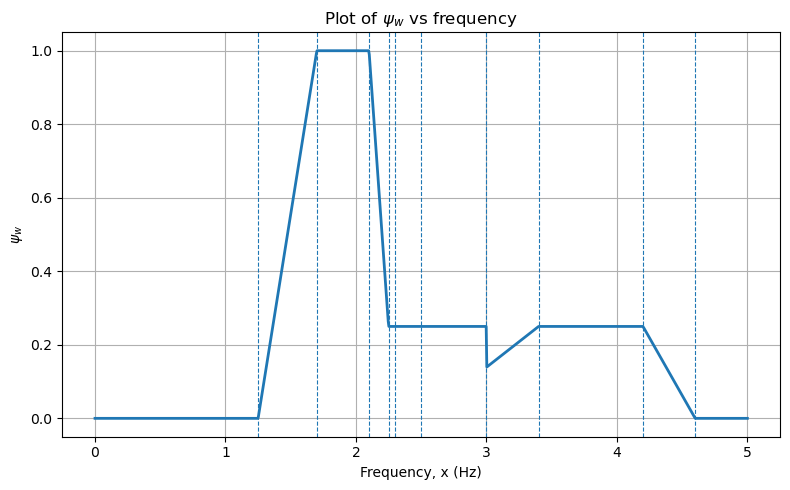

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# frequency range to plot
x_vals = np.linspace(0.0, 5.0, 1000)

# evaluate psi
y_vals = psi_w_h1(x_vals)

# plot
plt.figure(figsize=(8, 5))
plt.plot(x_vals, y_vals, linewidth=2)

# optional guide lines
for xv in [1.25, 1.70, 2.10, 2.25, 2.30, 2.50, 3.00, 3.40, 4.20, 4.60]:
    plt.axvline(xv, linestyle="--", linewidth=0.8)

plt.xlabel("Frequency, x (Hz)")
plt.ylabel(r"$\psi_w$")
plt.title(r"Plot of $\psi_w$ vs frequency")
plt.grid(True)
plt.tight_layout()
plt.show()